In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from pathlib import Path
from scipy import signal
from scipy.stats import kstest, norm
from scipy.stats import probplot

## Goal 1: Nyquist Sampling

### Section 5.3.1

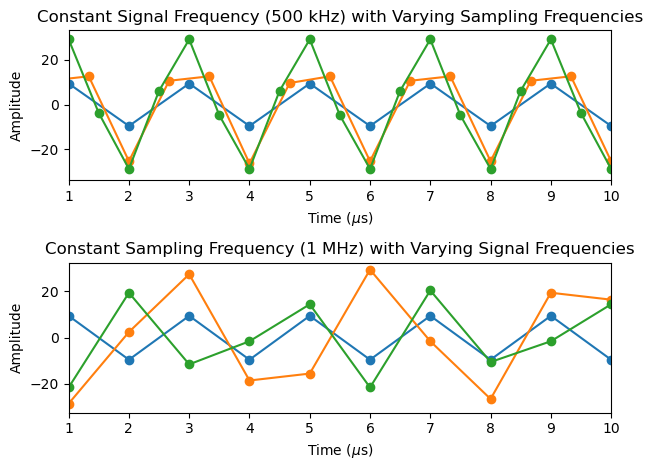

In [2]:
#data for signal frequency of 500 kHz, sampling frequency of 1MHz (Nyquist Limit)
data1 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1MHz_500kHz.npz")

#data for singal frequency 500kHz, sampling frequncy of 1MHz, 1.5MHz, and 2MHz
data2 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1.5MHz_500kHz.npz")
data3 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_2MHz_500kHz.npz")

#data for sampling frequency of 1.5MHz, signal frequency of 
data4 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1MHz_300kHz.npz")
data5 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1MHz_400kHz.npz")

D = 2 #what sample set (1, 2, 3, 4, or 5)

signal1 = data1["arr_0"][D]
signal2 = data2["arr_0"][D]
signal3 = data3["arr_0"][D]
signal4 = data4["arr_0"][D]
signal5 = data5["arr_0"][D]

signal1 = signal1 - np.mean(signal1)
signal2 = signal2 - np.mean(signal2)
signal3 = signal3 - np.mean(signal3)
signal4 = signal4 - np.mean(signal4)
signal5 = signal5 - np.mean(signal5)

time1 = np.arange(len(signal1)) / 1e6
time2 = np.arange(len(signal2)) / 1.5e6
time3 = np.arange(len(signal3)) / 2e6
time4 = np.arange(len(signal4)) / 1e6
time5 = np.arange(len(signal5)) / 1e6

plt.subplot(2,1,1)
plt.plot(time1 * 1e6, signal1, marker="o")
plt.plot(time2 * 1e6, signal2, marker="o")
plt.plot(time3 * 1e6, signal3, marker="o")
plt.xlim(1, 10)
plt.xlabel(r"Time ($\mu$s)")
plt.ylabel("Amplitude")
plt.title("Constant Signal Frequency (500 kHz) with Varying Sampling Frequencies")

plt.subplot(2,1,2)
plt.plot(time1 * 1e6, signal1, marker="o")
plt.plot(time4 * 1e6, signal4, marker="o")
plt.plot(time5 * 1e6, signal5, marker="o")
plt.xlim(1,10)
plt.xlabel(r"Time ($\mu$s)")
plt.ylabel("Amplitude")
plt.title("Constant Sampling Frequency (1 MHz) with Varying Signal Frequencies")
plt.tight_layout()
plt.show()

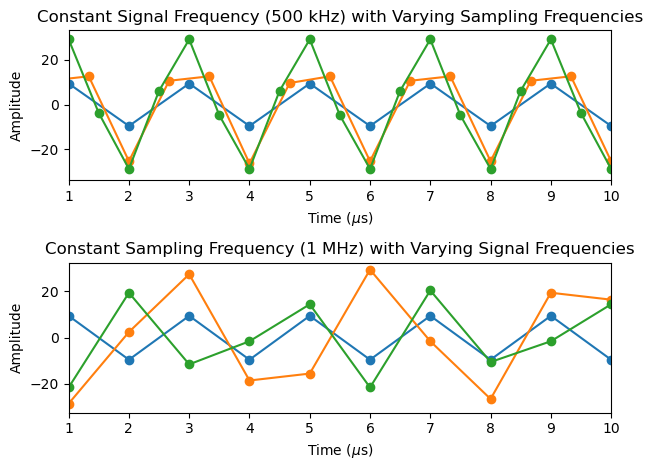

In [3]:
#data for signal frequency of 500 kHz, sampling frequency of 1MHz (Nyquist Limit)
data1 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1MHz_500kHz.npz")

#data for singal frequency 500kHz, sampling frequncy of 1MHz, 1.5MHz, and 2MHz
data2 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1.5MHz_500kHz.npz")
data3 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_2MHz_500kHz.npz")

#data for sampling frequency of 1.5MHz, signal frequency of 
data4 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1MHz_300kHz.npz")
data5 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1MHz_400kHz.npz")

D = 2 #what sample set (1, 2, 3, 4, or 5)

def nyquist(data, fs):
    signal = data["arr_0"][D]
    signal = signal - np.mean(signal)
    time = np.arange(len(signal)) / fs

    return plt.plot(time * 1e6, signal, marker="o")

plt.subplot(2, 1, 1)
nyquist(data1, 1e6)
nyquist(data2, 1.5e6)
nyquist(data3, 2e6)
plt.xlim(1, 10)
plt.xlabel(r"Time ($\mu$s)")
plt.ylabel("Amplitude")
plt.title("Constant Signal Frequency (500 kHz) with Varying Sampling Frequencies")

plt.subplot(2, 1, 2)
nyquist(data1, 1e6)
nyquist(data4, 1e6) 
nyquist(data5, 1e6)
plt.xlim(1,10)
plt.xlabel(r"Time ($\mu$s)")
plt.ylabel("Amplitude")
plt.title("Constant Sampling Frequency (1 MHz) with Varying Signal Frequencies")
plt.tight_layout()
plt.show()


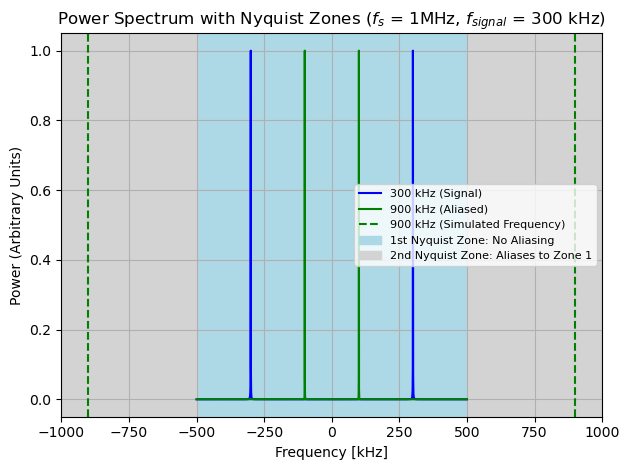

In [4]:
#Attempt to show first Nyquist Zone for signal 1, using 1MHz, 300kHz data (data4)
fs = 1e6 #Sampling frequency (Hz)
nyquist_freq = fs / 2
true_freq = 300e3 #Signal frequency (Hz)

#Variables for simulated signal
N = len(signal4)
time = np.arange(N) / fs
freq_sim1 = 900e3 #Simulated signal frequency (Hz)
signal_sim1 = np.cos(2 * np.pi * freq_sim1 * time)

#Fourier Transform and Power Spectrum of Signal Data
spectrum = np.fft.fft(signal4)
freq = np.fft.fftfreq(len(signal4), d = 1/fs)
spectrum_shift = np.fft.fftshift(spectrum)
freqs_shift = np.fft.fftshift(freq)
power = np.abs(spectrum_shift)**2

#Fourier Transform and Power Spectrum of Simulated 900 kHz Signal
spectrum_sim1 = np.fft.fft(signal_sim1)
power_sim1 = np.abs(np.fft.fftshift(spectrum_sim1))**2

#Labeling Nyquist Zones and Plotting Power Spectrum of 300 kHz signal and simulated 900 kHz signal
plt.plot(freqs_shift/1e3, power / np.max(power), color = "blue", label = "300 kHz (Signal)")
plt.plot(freqs_shift/1e3, power_sim1 / np.max(power_sim1), color = "green", label = "900 kHz (Aliased)")

#Labeling true frequency, simulated frequency, and aliased frequency

plt.axvline(freq_sim1/1e3, color = "green", linestyle = "--", label = "900 kHz (Simulated Frequency)")
plt.axvline(-freq_sim1/1e3, color = "green", linestyle = "--")

#Showing Nyquist Zones
for zone in range(1, 4):
    boundaries = zone * nyquist_freq
    color = "lightblue" if zone % 2 == 1 else "lightgray"
    if zone == 1:
        label_pos = "1st Nyquist Zone: No Aliasing"
        label_neg = "_nolegend_"
    elif zone == 2:
        label_pos = "2nd Nyquist Zone: Aliases to Zone 1"
        label_neg = "_nolegend_"
    else:
        label_pos = "_nolegend_"
        label_neg = "_nolegend_"

    plt.axvspan((zone - 1) * nyquist_freq/1e3, zone * nyquist_freq/1e3, color=color, label=label_pos)
    plt.axvspan(-zone * nyquist_freq/1e3, -(zone - 1) * nyquist_freq/1e3, color=color, label=label_neg)


plt.xlabel("Frequency [kHz]")
plt.ylabel("Power (Arbitrary Units)")
plt.title("Power Spectrum with Nyquist Zones ($f_s$ = 1MHz, $f_{signal}$ = 300 kHz)")
plt.legend(fontsize = 8)
plt.xlim(-1000, 1000)
plt.grid()
plt.tight_layout()
plt.show()

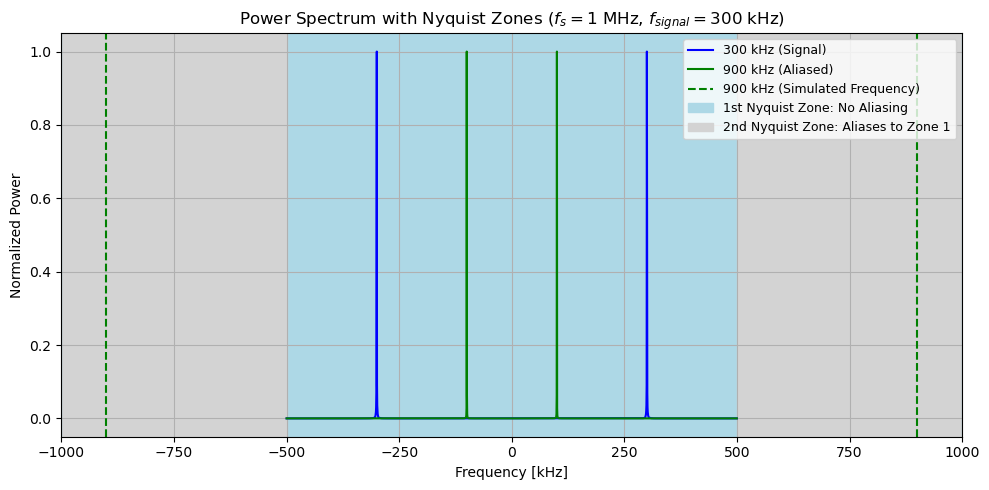

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Load the specific dataset: fs = 1 MHz, f_signal = 300 kHz
data = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1MHz_300kHz.npz")
signal = data["arr_0"][2]  # Using D = 2
signal = signal - np.mean(signal)

# Parameters
fs = 1e6          # Sampling frequency (Hz)
nyquist_freq = fs / 2
true_freq = 300e3 # Signal frequency (Hz)
N = len(signal)

# Simulated aliased frequency (900 kHz, in 2nd Nyquist zone)
f_alias = 900e3
time = np.arange(N) / fs
signal_alias = np.cos(2 * np.pi * f_alias * time)

# Compute power spectra
spectrum = np.fft.fft(signal)
freq = np.fft.fftfreq(N, d=1/fs)
spectrum_shift = np.fft.fftshift(spectrum)
freqs_shift = np.fft.fftshift(freq)
power = np.abs(spectrum_shift)**2

spectrum_alias = np.fft.fft(signal_alias)
power_alias = np.abs(np.fft.fftshift(spectrum_alias))**2

# Plot
plt.figure(figsize=(10, 5))
plt.plot(freqs_shift/1e3, power / np.max(power), color='blue', label='300 kHz (Signal)')
plt.plot(freqs_shift/1e3, power_alias / np.max(power_alias), color='green', label='900 kHz (Aliased)')

# Mark frequencies
plt.axvline(f_alias/1e3, color='green', linestyle='--', label='900 kHz (Simulated Frequency)')
plt.axvline(-f_alias/1e3, color='green', linestyle='--')

# Shade and label Nyquist zones (using your labeling logic)
for zone in range(1, 4):
    left = (zone - 1) * nyquist_freq
    right = zone * nyquist_freq
    color = 'lightblue' if zone % 2 == 1 else 'lightgray'
    
    if zone == 1:
        label_pos = '1st Nyquist Zone: No Aliasing'
        label_neg = '_nolegend_'
    elif zone == 2:
        label_pos = '2nd Nyquist Zone: Aliases to Zone 1'
        label_neg = '_nolegend_'
    else:
        label_pos = '_nolegend_'
        label_neg = '_nolegend_'
    
    plt.axvspan(left/1e3, right/1e3, color=color, label=label_pos)
    plt.axvspan(-right/1e3, -left/1e3, color=color, label=label_neg)

plt.xlabel('Frequency [kHz]')
plt.ylabel('Normalized Power')
plt.title(r'Power Spectrum with Nyquist Zones ($f_s = 1$ MHz, $f_{signal} = 300$ kHz)')
plt.legend(fontsize=9)
plt.xlim(-1000, 1000)
plt.grid()
plt.tight_layout()
plt.show()

## Goal 3: Bandpass Filter of SDR

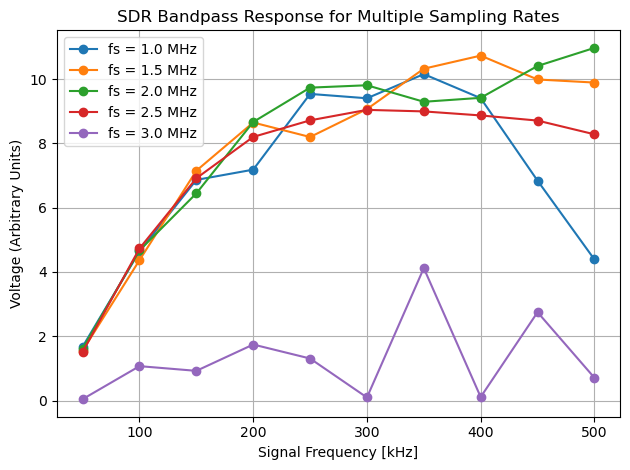

In [5]:
base_dir = Path("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter")

sampling_rates = np.array([1e6, 1.5e6, 2e6, 2.5e6, 3e6])
signal_freqs = np.array([50e3, 100e3, 150e3, 200e3, 250e3, 300e3, 350e3, 400e3, 450e3, 500e3])

files_by_fs = {
    fs: [
        base_dir
        / f"{fs/1e6:g}MHz_Sampling"
        / f"test_{fs/1e6:g}MHz_{int(f/1e3)}kHz.npz"
        for f in signal_freqs
    ]
    for fs in sampling_rates
}

def extract_peak_magnitude(filename, fs, f_sig, N):
    """
    Extract the average FFT peak magnitude at f_sig from an SDR data file
    with mutliple sample blocks.
    
    Parameters:
        filename : str
            Path to .npz file (expects data in 'arr_0')
        fs : float
            Sampling frequency (Hz)
        f_sig : float
            Signal frequency (Hz)
        N : int
            Number of samples to use per block
    
    Returns:
        peak_mag : float
            Average FFT magnitude at the signal frequency across all blocks
    """
    # Load the data
    data = np.load(filename)['arr_0']  # shape: (num_blocks, samples_per_block)

    # Trim each block to N samples (along last axis)
    signal = data[:, :N]  # shape: (num_blocks, N)

    # Create Hann window
    window = np.hanning(N)

    # Apply window to each block (broadcasts correctly)
    signal_win = signal * window

    # FFT along samples axis
    spectrum_mag = np.abs(np.fft.fft(signal_win, axis=1))

    # Frequency array
    freqs = np.fft.fftfreq(N, d=1/fs)

    # Index of closest bin to f_sig
    idx = np.argmin(np.abs(freqs - f_sig))

    # Take the average magnitude across blocks
    peak_mag = np.mean(spectrum_mag[:, idx])

    return peak_mag


plt.figure()

for fs in sampling_rates:
    magnitudes = []
    files = files_by_fs[fs]
    
    for f_sig, fname in zip(signal_freqs, files):
        peak_mag = extract_peak_magnitude(fname, fs, f_sig, N)
        magnitudes.append(peak_mag)
    
    # Convert to linear voltage
    fft_mag_volts = (np.array(magnitudes) / N) * 2
    
    # Plot
    plt.plot(signal_freqs / 1e3, fft_mag_volts, 'o-', label = f'fs = {fs/1e6} MHz')

plt.xlabel("Signal Frequency [kHz]")
plt.ylabel("Voltage (Arbitrary Units)")
plt.title("SDR Bandpass Response for Multiple Sampling Rates")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


## Goal 4: Spectral Leakage and Frequency Resolution

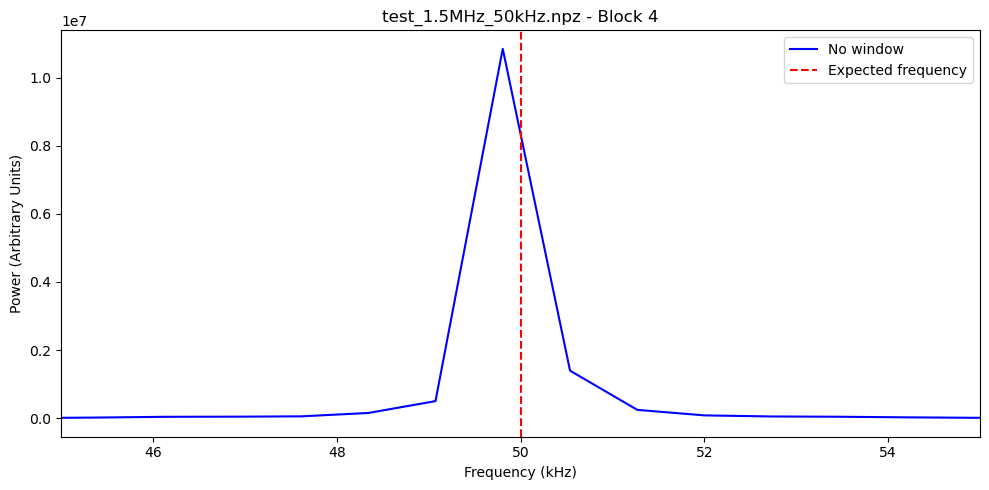

test_1.5MHz_50kHz.npz - Block 4: Frequency resolution Δf = 732.42 Hz


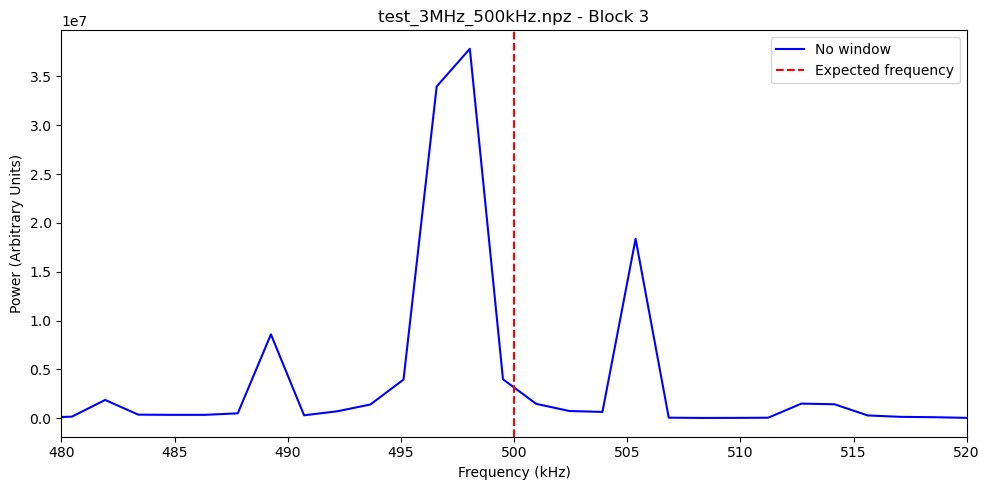

test_3MHz_500kHz.npz - Block 3: Frequency resolution Δf = 1464.84 Hz


In [6]:
# Dataset parameters
datasets = [
    {
        "file": r"C:\Users\medin\Downloads\Spring_2026\ASTRON121\LAB1_DATA\Bandpass Filter\1.5MHz_Sampling\test_1.5MHz_50kHz.npz",
        "fs": 1.5e6,
        "f_signal": 50e3,
        "zoom_range_khz": 5,
        "block_idx": 3  # chosen representative block
    },
    {
        "file": r"C:\Users\medin\Downloads\Spring_2026\ASTRON121\LAB1_DATA\Bandpass Filter\3MHz_Sampling\test_3MHz_500kHz.npz",
        "fs": 3e6,
        "f_signal": 500e3,
        "zoom_range_khz": 20,
        "block_idx": 2  # chosen representative block
    }
]

# Function to plot annotated spectrum
def plot_annotated_spectrum(x_block, fs, f_signal, zoom_range_khz, title):
    N = len(x_block)
    delta_f = fs / N
    
    # FFTs
    freqs = np.fft.fftfreq(N, 1/fs)
    
    X = np.fft.fft(x_block)
    
    power = np.abs(X)**2
    
    # Zoom range
    zoom_min = f_signal - zoom_range_khz * 1e3
    zoom_max = f_signal + zoom_range_khz * 1e3
    
    plt.figure(figsize = (10,5))
    
    # Plot spectra
    plt.plot(freqs[:N//2]/1e3, power[:N//2], label = 'No window', color = 'blue')
        
    # Expected frequency line
    plt.axvline(f_signal/1e3, color = 'red', linestyle = '--', label = 'Expected frequency')
    
    plt.xlim(zoom_min/1e3, zoom_max/1e3)
    plt.xlabel('Frequency (kHz)')
    #plt.yscale('log')
    plt.ylabel('Power (Arbitrary Units)')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"{title}: Frequency resolution Δf = {delta_f:.2f} Hz")

# Process both datasets
for ds in datasets:
    data = np.load(ds["file"])
    x = data[data.files[0]]
    
    # Ensure 2D: blocks × samples
    if x.ndim == 1:
        x = x[np.newaxis, :]
    
    block = x[ds["block_idx"]]
    title = f"{os.path.basename(ds['file'])} - Block {ds['block_idx'] + 1}"
    
    plot_annotated_spectrum(block, ds["fs"], ds["f_signal"], ds["zoom_range_khz"], title)


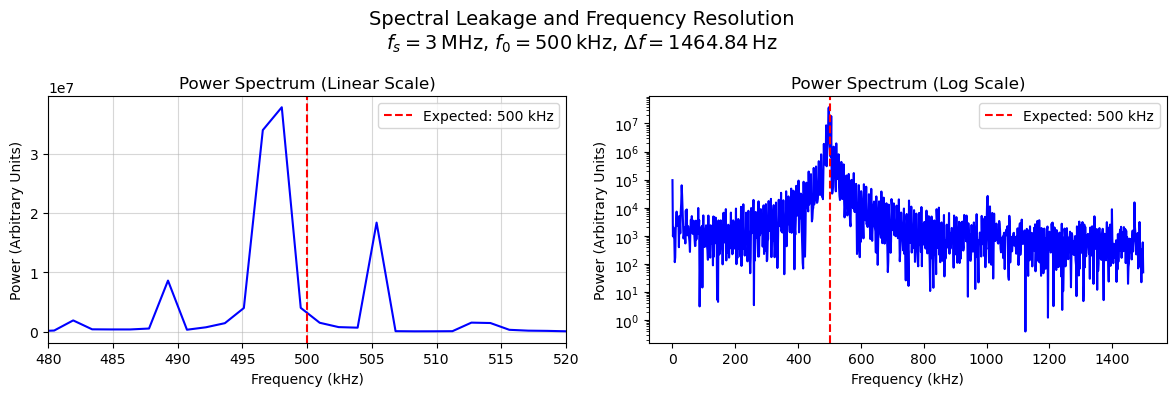

Frequency resolution Δf = 1464.84 Hz
Number of samples N = 2048


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Single dataset: 3 MHz sampling, 500 kHz signal
file_path = r"C:\Users\medin\Downloads\Spring_2026\ASTRON121\LAB1_DATA\Bandpass Filter\3MHz_Sampling\test_3MHz_500kHz.npz"
fs = 3.0e6
f_signal = 500e3
zoom_range_khz = 20
block_idx = 2  # Block 3 (0‑indexed)

# Load data
data = np.load(file_path)
x = data[data.files[0]]
if x.ndim == 1:
    x = x[np.newaxis, :]
block = x[block_idx]

N = len(block)
delta_f = fs / N

# FFT
freqs = np.fft.fftfreq(N, 1/fs)
X = np.fft.fft(block)
power = np.abs(X)**2

# Zoom range
zoom_min = f_signal - zoom_range_khz * 1e3
zoom_max = f_signal + zoom_range_khz * 1e3

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
ax1 = axes[0]
ax1.plot(freqs[:N//2]/1e3, power[:N//2], color='blue', linewidth=1.5)
ax1.axvline(f_signal/1e3, color='red', linestyle='--', label=f'Expected: {f_signal/1e3:.0f} kHz')
ax1.set_xlim(zoom_min/1e3, zoom_max/1e3)
ax1.set_xlabel('Frequency (kHz)')
ax1.set_ylabel('Power (Arbitrary Units)')
ax1.set_title('Power Spectrum (Linear Scale)')
ax1.legend()
ax1.grid(alpha=0.5)

# Log scale
ax2 = axes[1]
ax2.plot(freqs[:N//2]/1e3, power[:N//2], color='blue', linewidth=1.5)
ax2.axvline(f_signal/1e3, color='red', linestyle='--', label=f'Expected: {f_signal/1e3:.0f} kHz')
ax2.set_xlabel('Frequency (kHz)')
ax2.set_ylabel('Power (Arbitrary Units)')
ax2.set_yscale('log')
ax2.set_title('Power Spectrum (Log Scale)')
ax2.legend()

plt.suptitle(f'Spectral Leakage and Frequency Resolution\n$f_s = 3$ MHz, $f_0 = 500$ kHz, $\\Delta f = {delta_f:.2f}$ Hz', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Frequency resolution Δf = {delta_f:.2f} Hz")
print(f"Number of samples N = {N}")

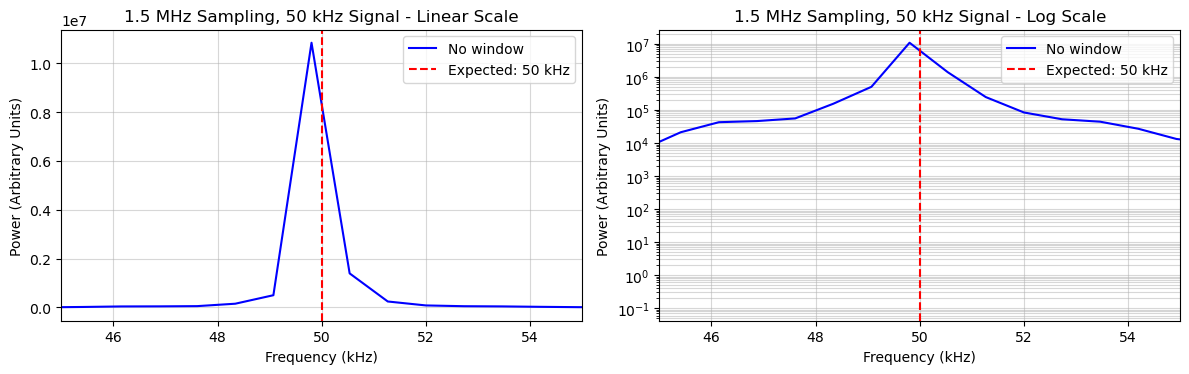

1.5 MHz Sampling, 50 kHz Signal: Frequency resolution Δf = 732.42 Hz



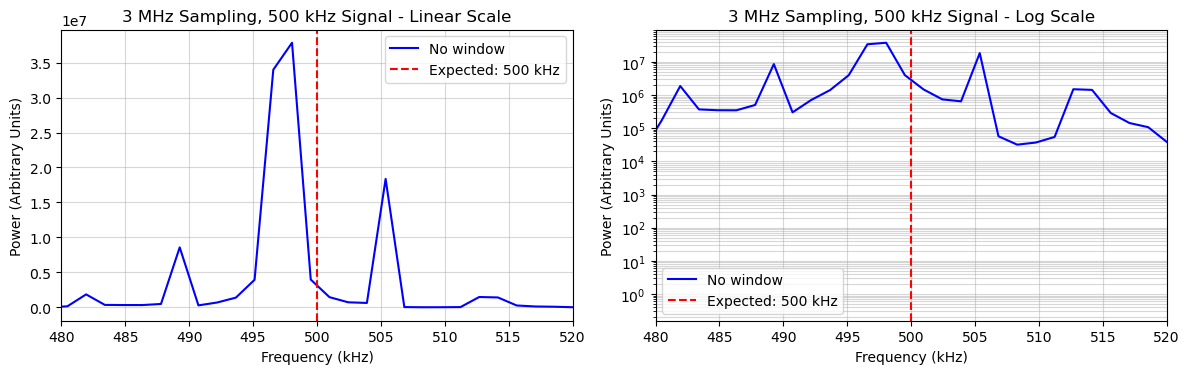

3 MHz Sampling, 500 kHz Signal: Frequency resolution Δf = 1464.84 Hz


Frequency Resolution Summary
1.5 MHz Sampling, 50 kHz Signal          Δf =   732.42 Hz  (N = 2048 samples)
3 MHz Sampling, 500 kHz Signal           Δf =  1464.84 Hz  (N = 2048 samples)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Dataset parameters
datasets = [
    {
        "file": r"C:\Users\medin\Downloads\Spring_2026\ASTRON121\LAB1_DATA\Bandpass Filter\1.5MHz_Sampling\test_1.5MHz_50kHz.npz",
        "fs": 1.5e6,
        "f_signal": 50e3,
        "zoom_range_khz": 5,
        "block_idx": 3,
        "label": "1.5 MHz Sampling, 50 kHz Signal"
    },
    {
        "file": r"C:\Users\medin\Downloads\Spring_2026\ASTRON121\LAB1_DATA\Bandpass Filter\3MHz_Sampling\test_3MHz_500kHz.npz",
        "fs": 3e6,
        "f_signal": 500e3,
        "zoom_range_khz": 20,
        "block_idx": 2,
        "label": "3 MHz Sampling, 500 kHz Signal"
    }
]

def plot_spectra_comparison(x_block, fs, f_signal, zoom_range_khz, title_label):
    N = len(x_block)
    delta_f = fs / N  # Frequency resolution
    
    # FFT
    freqs = np.fft.fftfreq(N, 1/fs)
    X = np.fft.fft(x_block)
    power = np.abs(X)**2
    
    # Zoom range
    zoom_min = f_signal - zoom_range_khz * 1e3
    zoom_max = f_signal + zoom_range_khz * 1e3
    
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Linear scale
    ax1 = axes[0]
    ax1.plot(freqs[:N//2]/1e3, power[:N//2], color='blue', label='No window', linewidth=1.5)
    ax1.axvline(f_signal/1e3, color='red', linestyle='--', label=f'Expected: {f_signal/1e3:.0f} kHz')
    ax1.set_xlim(zoom_min/1e3, zoom_max/1e3)
    ax1.set_xlabel('Frequency (kHz)')
    ax1.set_ylabel('Power (Arbitrary Units)')
    ax1.set_title(f'{title_label} - Linear Scale')
    ax1.legend()
    ax1.grid(alpha=0.5)
    
    # Log scale
    ax2 = axes[1]
    ax2.plot(freqs[:N//2]/1e3, power[:N//2], color='blue', label='No window', linewidth=1.5)
    ax2.axvline(f_signal/1e3, color='red', linestyle='--', label=f'Expected: {f_signal/1e3:.0f} kHz')
    ax2.set_xlim(zoom_min/1e3, zoom_max/1e3)
    ax2.set_xlabel('Frequency (kHz)')
    ax2.set_ylabel('Power (Arbitrary Units)')
    ax2.set_yscale('log')
    ax2.set_title(f'{title_label} - Log Scale')
    ax2.legend()
    ax2.grid(alpha=0.5, which='both')
    
    plt.tight_layout()
    plt.show()
    
    print(f"{title_label}: Frequency resolution Δf = {delta_f:.2f} Hz\n")
    return delta_f

# Process both datasets
delta_fs = []
for ds in datasets:
    data = np.load(ds["file"])
    x = data[data.files[0]]
    
    if x.ndim == 1:
        x = x[np.newaxis, :]
    
    block = x[ds["block_idx"]]
    title_label = ds["label"]
    
    delta_f = plot_spectra_comparison(block, ds["fs"], ds["f_signal"], ds["zoom_range_khz"], title_label)
    delta_fs.append(delta_f)

## Goal 5: Noise Analysis

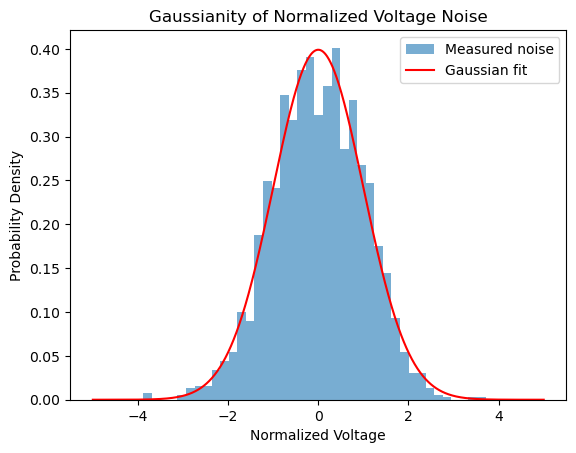

In [8]:
noise_data = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Noise Analysis/noisedata_real.npz")
D = 1

noise_data = noise_data["arr_0"][D]

noise_mean = np.mean(noise_data)
noise_std = np.std(noise_data)

x = np.linspace(-5, 5, 1000)
gauss = (1 / np.sqrt(2 * np.pi)) * np.exp(-x**2/2)

normed_noise_data = (noise_data - noise_mean) / noise_std

plt.hist(normed_noise_data, bins = 40, density = True, alpha = 0.6, label = "Measured noise")
plt.plot(x, gauss, 'r', label="Gaussian fit")

plt.xlabel("Normalized Voltage")
plt.ylabel("Probability Density")
plt.title("Gaussianity of Normalized Voltage Noise")
plt.legend()
plt.show()


K-S test: statistic = 0.0234, p-value = 0.2078
Data appears Gaussian? True


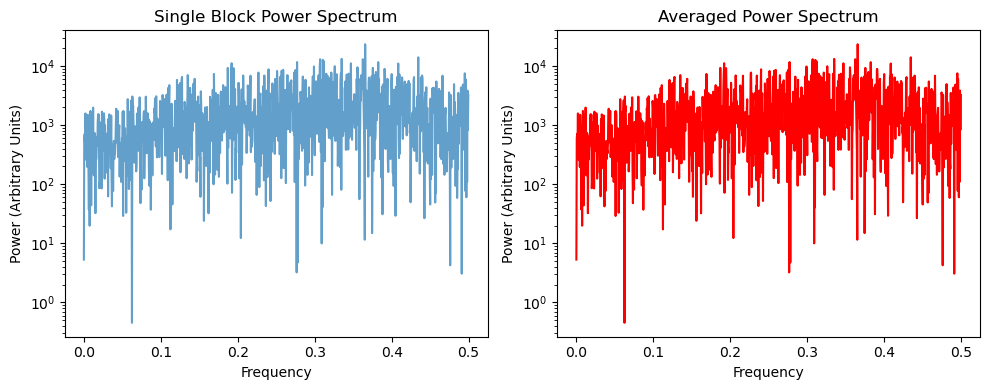

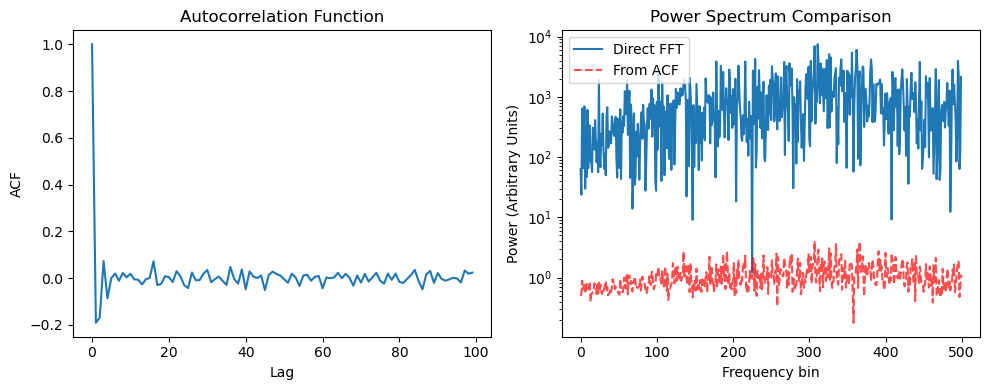

In [9]:
normed_noise = normed_noise_data  # Your normalized data

# 1. Quantitative Gaussianity test
ks_stat, p_value = kstest(normed_noise, 'norm')
print(f"K-S test: statistic = {ks_stat:.4f}, p-value = {p_value:.4f}")
print(f"Data appears Gaussian? {p_value > 0.05}")

# 2. Split into blocks and compute power spectra
block_size = 2000
num_blocks = len(normed_noise) // block_size
power_spectra = []

for i in range(num_blocks):
    block = normed_noise[i * block_size:(i+1)*block_size]
    
    # Compute power spectrum
    fft = np.fft.fft(block)
    power = np.abs(fft)**2
    power_spectra.append(power)

power_spectra = np.array(power_spectra)
avg_power = np.mean(power_spectra, axis = 0)
freqs = np.fft.fftfreq(block_size)

# 3. Plot single vs averaged power spectrum
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
plt.plot(freqs[:block_size//2], power_spectra[0][:block_size//2], alpha = 0.7, label = 'Single block')
plt.xlabel('Frequency')
plt.ylabel('Power (Arbitrary Units)')
plt.title('Single Block Power Spectrum')
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.plot(freqs[:block_size//2], avg_power[:block_size//2], 'r-', label = f'Avg of {num_blocks} blocks')
plt.xlabel('Frequency')
plt.ylabel('Power (Arbitrary Units)')
plt.title('Averaged Power Spectrum')
plt.yscale('log')
plt.tight_layout()
plt.show()

# 5. Autocorrelation Function
acf = np.correlate(normed_noise, normed_noise, mode = 'full')
acf = acf[len(acf)//2:]  # Take positive lags only
acf = acf / acf[0]  # Normalize

# Power spectrum from ACF
ps_from_acf = np.abs(np.fft.fft(acf[:1000]))

# Compare with direct FFT
ps_direct = np.abs(np.fft.fft(normed_noise[:1000]))**2

plt.figure(figsize =(10, 4))
plt.subplot(1, 2, 1)
plt.plot(acf[:100])
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.title('Autocorrelation Function')

plt.subplot(1, 2, 2)
plt.plot(ps_direct[:500], label = 'Direct FFT')
plt.plot(ps_from_acf[:500], 'r--', alpha = 0.7, label = 'From ACF')
plt.yscale('log')
plt.xlabel('Frequency bin')
plt.ylabel('Power (Arbitrary Units)')
plt.title('Power Spectrum Comparison')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Check FWHM relationship
print("\n=== FWHM Analysis ===")
# Estimate FWHM of ACF (in samples)
acf_half = np.argmax(acf < 0.5)
print(f"ACF FWHM ≈ {acf_half} samples")

# Estimate FWHM of PSD (in frequency bins)
psd_peak = np.max(psd_direct)
psd_half_idx = np.where(psd_direct[:512] > psd_peak/2)[0]
if len(psd_half_idx) > 1:
    psd_fwhm = psd_half_idx[-1] - psd_half_idx[0]
    print(f"PSD FWHM ≈ {psd_fwhm} frequency bins")
    print(f"Product (≈1 for Fourier pairs): {acf_half * psd_fwhm / len(subset):.3f}")


=== FWHM Analysis ===
ACF FWHM ≈ 1 samples


NameError: name 'psd_direct' is not defined

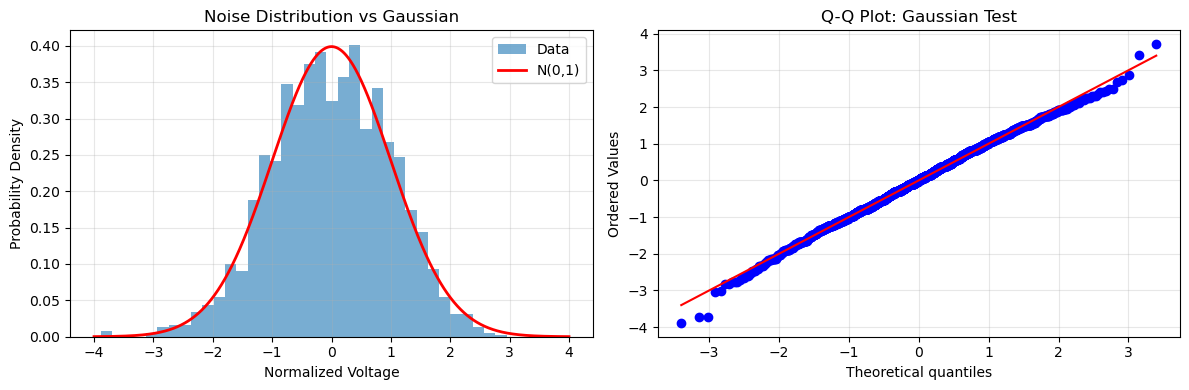

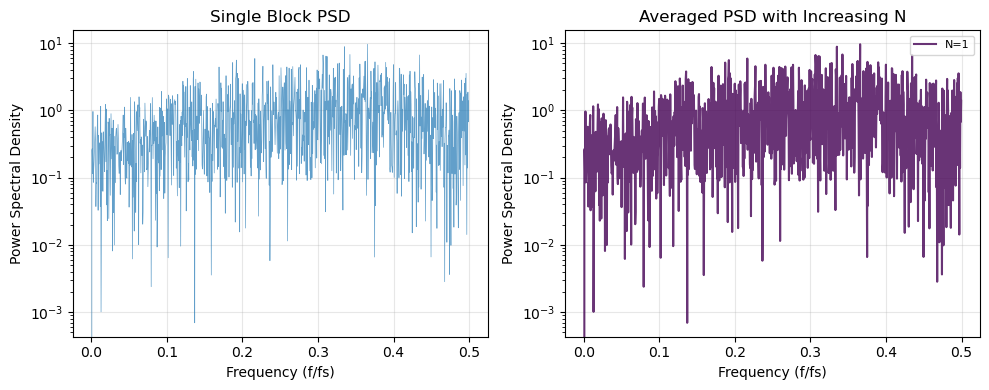


=== ACF Analysis ===


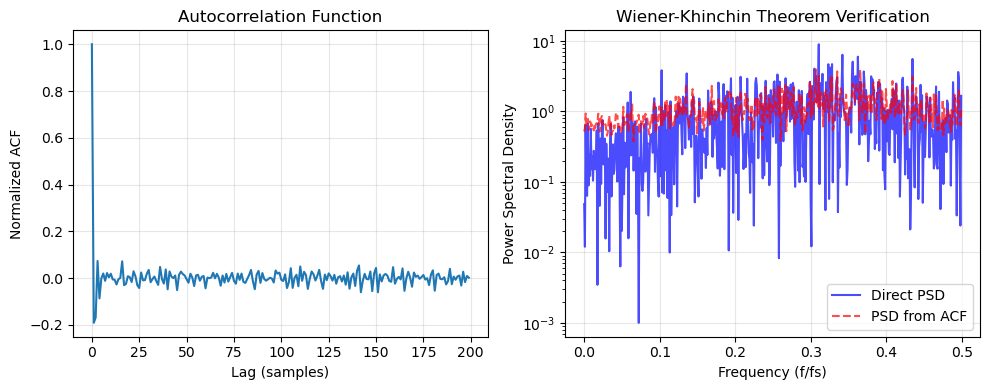

In [ ]:
# Load and normalize your data (as before)
noise_data = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Noise Analysis/noisedata_real.npz")
D = 1
raw_data = noise_data["arr_0"][D]

# Normalize properly
data_mean = np.mean(raw_data)
data_std = np.std(raw_data)
normed_data = (raw_data - data_mean) / data_std

# 1. Better Gaussianity analysis
plt.figure(figsize = (12, 4))

# Histogram with better binning
plt.subplot(1, 2, 1)
counts, bins, _ = plt.hist(normed_data, bins = 40, density = True, alpha = 0.6, label = 'Data')
x = np.linspace(-4, 4, 1000)
gaussian = norm.pdf(x, 0, 1)

plt.plot(x, gaussian, 'r-', linewidth = 2, label = 'N(0,1)')
plt.xlabel('Normalized Voltage')
plt.ylabel('Probability Density')
plt.title('Noise Distribution vs Gaussian')
plt.legend()
plt.grid(True, alpha = 0.3)

# Q-Q plot for better comparison
plt.subplot(1, 2, 2)
probplot(normed_data, dist = "norm", plot = plt)
plt.title('Q-Q Plot: Gaussian Test')
plt.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

# 2. Improved Power Spectrum Analysis
block_size = 2048  # Power of 2 for FFT efficiency
n_samples = len(normed_data)
num_blocks = n_samples // block_size

# Extract blocks
blocks = [normed_data[i * block_size:(i+1) * block_size] 
          for i in range(num_blocks)][:16]  # Use first 16 blocks

# Compute power spectra
freqs = np.fft.fftfreq(block_size)
psd_list = []

for block in blocks:
    fft = np.fft.fft(block)
    psd = np.abs(fft)**2 / block_size  # Proper normalization
    psd_list.append(psd)

psd_list = np.array(psd_list)

# Plot single vs averaged PSD
plt.figure(figsize = (10, 4))

# Single block
plt.subplot(1, 2, 1)
plt.plot(freqs[:block_size//2], psd_list[0][:block_size//2], 
         alpha = 0.7, linewidth = 0.5)
plt.xlabel('Frequency (f/fs)')
plt.ylabel('Power Spectral Density')
plt.title('Single Block PSD')
plt.yscale('log')
plt.grid(True, alpha = 0.3)

# Averaged with increasing N
plt.subplot(1, 2, 2)
colors = plt.cm.viridis(np.linspace(0, 1, 5))
for i, n_avg in enumerate([1, 2, 4, 8, 16]):
    if n_avg <= len(psd_list):
        avg_psd = np.mean(psd_list[:n_avg], axis = 0)
        plt.plot(freqs[:block_size//2], avg_psd[:block_size//2], 
                 color = colors[i], alpha = 0.8, 
                 label = f'N={n_avg}')

plt.xlabel('Frequency (f/fs)')
plt.ylabel('Power Spectral Density')
plt.title('Averaged PSD with Increasing N')
plt.yscale('log')
plt.legend(fontsize = 8)
plt.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

# 4. ACF Analysis
print("\n=== ACF Analysis ===")
# Use a subset for ACF
subset = normed_data[:4096]
acf = np.correlate(subset, subset, mode = 'full')
acf = acf[len(acf)//2:]  # Positive lags
acf = acf / acf[0]  # Normalize

# Power spectrum from ACF (Wiener-Khinchin theorem)
psd_from_acf = np.abs(np.fft.fft(acf[:1024]))
freqs_acf = np.fft.fftfreq(len(psd_from_acf))

# Direct PSD for comparison
psd_direct = np.abs(np.fft.fft(subset[:1024]))**2 / 1024

plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
plt.plot(acf[:200])
plt.xlabel('Lag (samples)')
plt.ylabel('Normalized ACF')
plt.title('Autocorrelation Function')
plt.grid(True, alpha = 0.3)

plt.subplot(1, 2, 2)
plt.plot(freqs_acf[:512], psd_direct[:512], 'b-', alpha = 0.7, label = 'Direct PSD')
plt.plot(freqs_acf[:512], psd_from_acf[:512], 'r--', alpha = 0.7, label = 'PSD from ACF')
plt.xlabel('Frequency (f/fs)')
plt.ylabel('Power Spectral Density')
plt.title('Wiener-Khinchin Theorem Verification')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

Noise data: 2048 samples, ν_s = 2.4 MHz

--- Conjugate Symmetry Check ---
For real signals: V(-f) = conjugate(V(+f))
Frequency | V(+f) | V(-f) | Match?
--------------------------------------------------
   9.4 kHz |   56.58 -89.06j |   56.58 +89.06j | ✓ (err=0.00e+00)
  49.2 kHz |  -31.42 -30.91j |  -31.42 +30.91j | ✓ (err=1.80e-16)
  99.6 kHz |  -49.82 +30.87j |  -49.82 -30.87j | ✓ (err=1.21e-16)
 199.2 kHz |   -6.09 +32.78j |   -6.09 -32.78j | ✓ (err=1.07e-16)


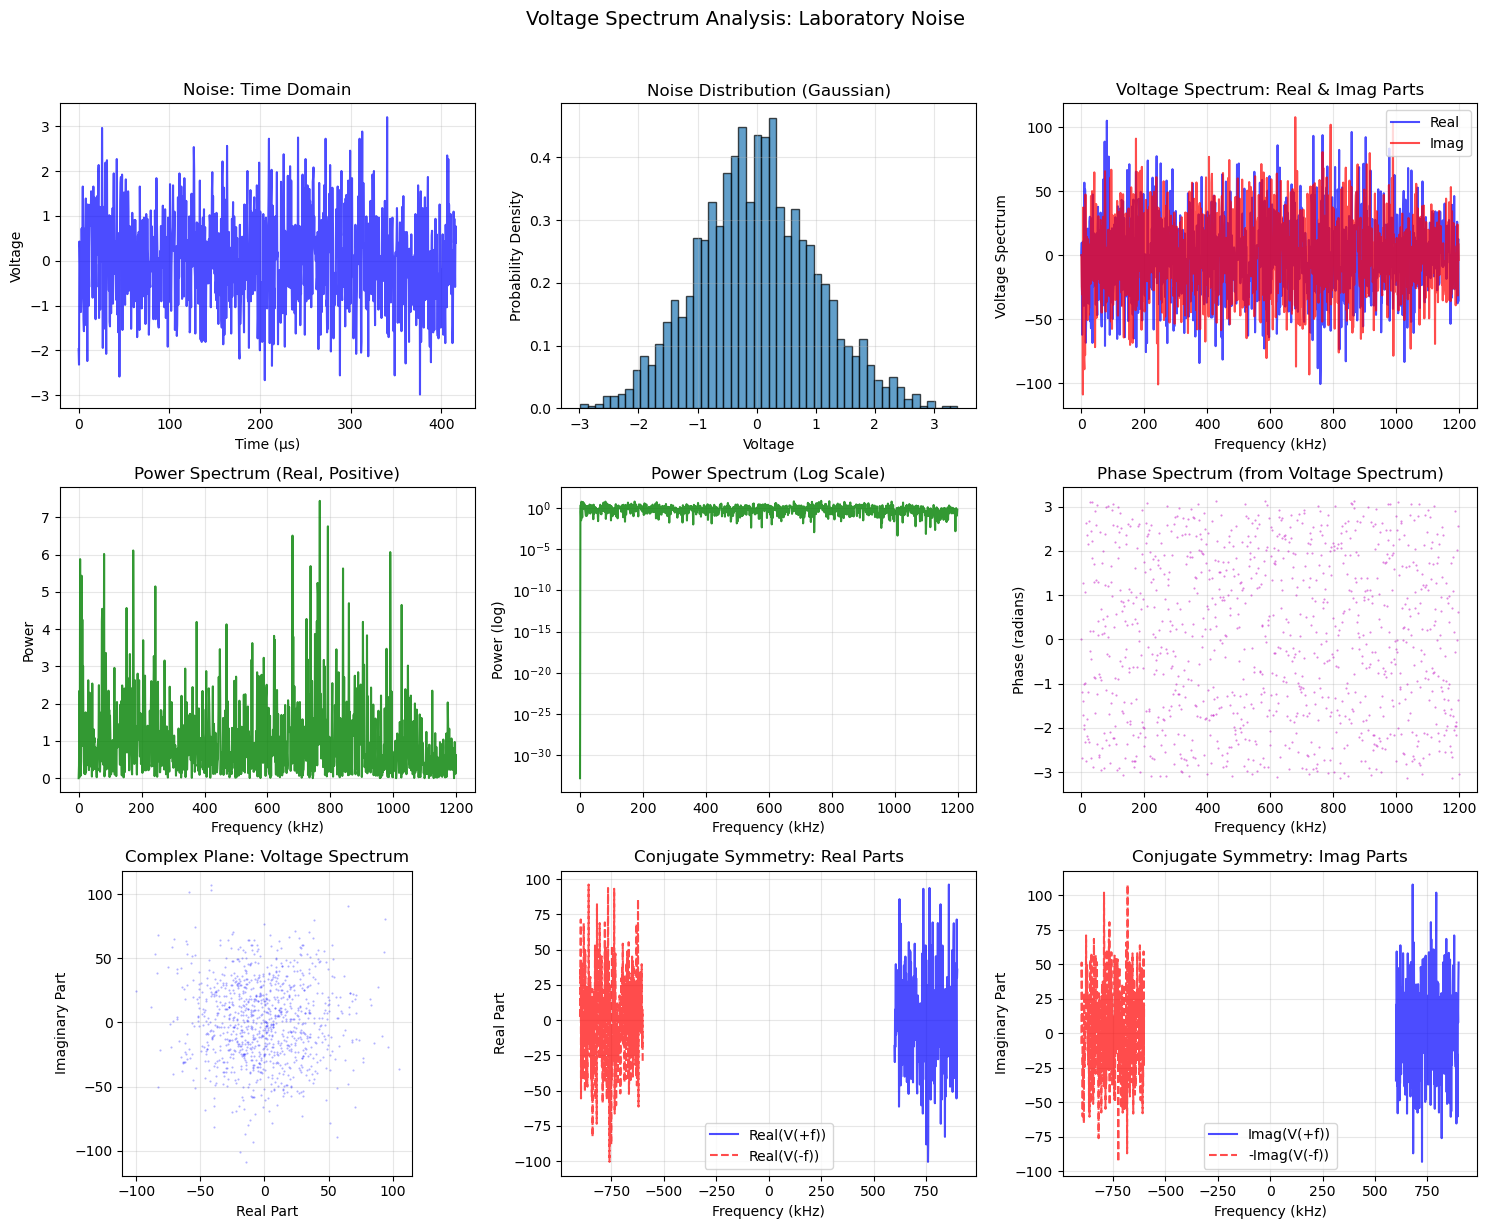


KEY INSIGHTS FOR GOAL 3 (Voltage Spectra)

    1. VOLTAGE SPECTRUM is COMPLEX:
       - Contains both magnitude AND phase information
       - Real and imaginary parts are both meaningful

    2. POWER SPECTRUM is REAL:
       - Only magnitude information (|V(f)|²)
       - Phase information is LOST

    3. CONJUGATE SYMMETRY for real signals:
       - V(-f) = V*(+f) [complex conjugate]
       - Real part is EVEN: Re[V(-f)] = Re[V(+f)]
       - Imag part is ODD: Im[V(-f)] = -Im[V(+f)]

    4. NOISE CHARACTERISTICS:
       - Voltage spectrum components are complex Gaussian
       - Phase is uniformly distributed (0 to 2π)
       - Power spectrum is flat (white noise)
    


In [ ]:
# Voltage Spectrum of Noise Analysis
def analyze_noise_voltage_spectrum():
    """
    Analyze voltage spectrum of lab noise
    """
    # Load your noise data (from Goal 5)
    noise_file = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Noise Analysis/noisedata_real.npz"
    noise_data = np.load(noise_file)
    
    # Use first dataset
    D = 0
    raw_noise = noise_data["arr_0"][D].astype(float)
    
    # Normalize
    noise = (raw_noise - np.mean(raw_noise)) / np.std(raw_noise)
    N = len(noise)
    ν_s = 2.4e6  # Adjust if different
    
    print(f"Noise data: {N} samples, ν_s = {ν_s/1e6:.1f} MHz")
    
    # 1. Compute Voltage Spectrum (Complex!)
    voltage_spec = np.fft.fft(noise)  # COMPLEX voltage spectrum
    power_spec = np.abs(voltage_spec)**2 / N  # Real power spectrum
    
    freqs = np.fft.fftfreq(N, d=1/ν_s)
    
    # ============================================
    # 2. Plot Time Domain
    # ============================================
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    # Time domain
    t = np.arange(N) / ν_s * 1e6  # microseconds
    axes[0, 0].plot(t[:1000], noise[:1000], 'b-', alpha=0.7)
    axes[0, 0].set_xlabel('Time (μs)')
    axes[0, 0].set_ylabel('Voltage')
    axes[0, 0].set_title('Noise: Time Domain')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Histogram of time samples
    axes[0, 1].hist(noise, bins=50, density=True, alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('Voltage')
    axes[0, 1].set_ylabel('Probability Density')
    axes[0, 1].set_title('Noise Distribution (Gaussian)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # ============================================
    # 3. Plot VOLTAGE SPECTRUM (Complex!)
    # ============================================
    # Real part of voltage spectrum
    axes[0, 2].plot(freqs[:N//2]/1e3, voltage_spec[:N//2].real, 'b-', alpha=0.7, label='Real')
    axes[0, 2].plot(freqs[:N//2]/1e3, voltage_spec[:N//2].imag, 'r-', alpha=0.7, label='Imag')
    axes[0, 2].set_xlabel('Frequency (kHz)')
    axes[0, 2].set_ylabel('Voltage Spectrum')
    axes[0, 2].set_title('Voltage Spectrum: Real & Imag Parts')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # ============================================
    # 4. Plot POWER SPECTRUM (for comparison)
    # ============================================
    axes[1, 0].plot(freqs[:N//2]/1e3, power_spec[:N//2], 'g-', alpha=0.8)
    axes[1, 0].set_xlabel('Frequency (kHz)')
    axes[1, 0].set_ylabel('Power')
    axes[1, 0].set_title('Power Spectrum (Real, Positive)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Log scale
    axes[1, 1].plot(freqs[:N//2]/1e3, power_spec[:N//2], 'g-', alpha=0.8)
    axes[1, 1].set_xlabel('Frequency (kHz)')
    axes[1, 1].set_ylabel('Power (log)')
    axes[1, 1].set_title('Power Spectrum (Log Scale)')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
    
    # ============================================
    # 5. Phase Information (from Voltage Spectrum)
    # ============================================
    phase = np.angle(voltage_spec[:N//2])
    magnitude = np.abs(voltage_spec[:N//2])
    
    # Phase vs frequency
    axes[1, 2].plot(freqs[:N//2]/1e3, phase, 'm.', markersize=1, alpha=0.5)
    axes[1, 2].set_xlabel('Frequency (kHz)')
    axes[1, 2].set_ylabel('Phase (radians)')
    axes[1, 2].set_title('Phase Spectrum (from Voltage Spectrum)')
    axes[1, 2].grid(True, alpha=0.3)
    
    # ============================================
    # 6. Complex Plane Representation
    # ============================================
    # Scatter plot of real vs imag parts
    axes[2, 0].plot(voltage_spec[:N//2].real, voltage_spec[:N//2].imag, 
                   'b.', markersize=1, alpha=0.3)
    axes[2, 0].set_xlabel('Real Part')
    axes[2, 0].set_ylabel('Imaginary Part')
    axes[2, 0].set_title('Complex Plane: Voltage Spectrum')
    axes[2, 0].grid(True, alpha=0.3)
    axes[2, 0].set_aspect('equal')
    
    # ============================================
    # 7. Negative vs Positive Frequency Symmetry
    # ============================================
    # For REAL signals: V(-f) = V*(f) (conjugate symmetry)
    # Let's check this
    
    # Take a few frequency pairs
    test_freqs = [10, 50, 100, 200]  # kHz
    test_indices = [int(f * 1e3 * N / ν_s) for f in test_freqs]
    
    print("\n--- Conjugate Symmetry Check ---")
    print("For real signals: V(-f) = conjugate(V(+f))")
    print("Frequency | V(+f) | V(-f) | Match?")
    print("-" * 50)
    
    symmetry_errors = []
    for idx in test_indices:
        if idx < N//2 and idx > 0:
            v_pos = voltage_spec[idx]
            v_neg = voltage_spec[-idx]
            # Check if v_neg ≈ conj(v_pos)
            error = np.abs(v_neg - np.conj(v_pos)) / np.abs(v_pos)
            symmetry_errors.append(error)
            
            print(f"{freqs[idx]/1e3:6.1f} kHz | {v_pos.real:7.2f}{v_pos.imag:+7.2f}j | "
                  f"{v_neg.real:7.2f}{v_neg.imag:+7.2f}j | "
                  f"{'✓' if error < 0.01 else '✗'} (err={error:.2e})")
    
    # Plot symmetry
    pos_freqs = freqs[N//4:3*N//8]  # Positive frequencies
    neg_freqs = freqs[5*N//8:3*N//4]  # Corresponding negative
    
    axes[2, 1].plot(pos_freqs/1e3, voltage_spec[N//4:3*N//8].real, 
                   'b-', label='Real(V(+f))', alpha=0.7)
    axes[2, 1].plot(neg_freqs/1e3, voltage_spec[5*N//8:3*N//4].real, 
                   'r--', label='Real(V(-f))', alpha=0.7)
    axes[2, 1].set_xlabel('Frequency (kHz)')
    axes[2, 1].set_ylabel('Real Part')
    axes[2, 1].set_title('Conjugate Symmetry: Real Parts')
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)
    
    axes[2, 2].plot(pos_freqs/1e3, voltage_spec[N//4:3*N//8].imag, 
                   'b-', label='Imag(V(+f))', alpha=0.7)
    axes[2, 2].plot(neg_freqs/1e3, -voltage_spec[5*N//8:3*N//4].imag,  # Note: -imag
                   'r--', label='-Imag(V(-f))', alpha=0.7)
    axes[2, 2].set_xlabel('Frequency (kHz)')
    axes[2, 2].set_ylabel('Imaginary Part')
    axes[2, 2].set_title('Conjugate Symmetry: Imag Parts')
    axes[2, 2].legend()
    axes[2, 2].grid(True, alpha=0.3)
    
    plt.suptitle('Voltage Spectrum Analysis: Laboratory Noise', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # 8. Key Insights for Report
    # ============================================
    print("\n" + "="*60)
    print("KEY INSIGHTS FOR GOAL 3 (Voltage Spectra)")
    print("="*60)
    print("""
    1. VOLTAGE SPECTRUM is COMPLEX:
       - Contains both magnitude AND phase information
       - Real and imaginary parts are both meaningful
    
    2. POWER SPECTRUM is REAL:
       - Only magnitude information (|V(f)|²)
       - Phase information is LOST
    
    3. CONJUGATE SYMMETRY for real signals:
       - V(-f) = V*(+f) [complex conjugate]
       - Real part is EVEN: Re[V(-f)] = Re[V(+f)]
       - Imag part is ODD: Im[V(-f)] = -Im[V(+f)]
    
    4. NOISE CHARACTERISTICS:
       - Voltage spectrum components are complex Gaussian
       - Phase is uniformly distributed (0 to 2π)
       - Power spectrum is flat (white noise)
    """)
    
    return voltage_spec, power_spec, freqs

# Run the analysis
voltage_spec, power_spec, freqs = analyze_noise_voltage_spectrum()

## Goal 6: SSB and DSB Mixers

=== DSB DATA FILE INSPECTION ===
File: C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/DSB/fir_300_285_0.npz
Keys in file: ['arr_0']

--- Key: 'arr_0' ---
  Shape: (16, 2048)
  Data type: int8
  Size: 32768 elements
  Type: Real data
  Range: [-113.000, 115.000]
  First 5 values: multi-dimensional

2D data shape (16, 2048) - possibly I and Q channels


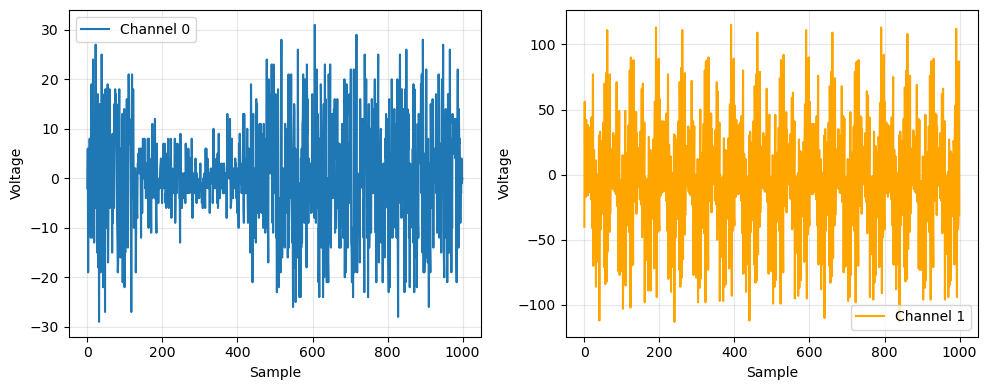

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# STEP 1: Load and inspect the DSB data
dsb_file = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/DSB/fir_300_285_0.npz"  # Replace with your actual path if needed
dsb_data = np.load(dsb_file)

print("=== DSB DATA FILE INSPECTION ===")
print(f"File: {dsb_file}")
print(f"Keys in file: {list(dsb_data.keys())}")

# Let's examine each key
for key in dsb_data.keys():
    data = dsb_data[key]
    print(f"\n--- Key: '{key}' ---")
    print(f"  Shape: {data.shape}")
    print(f"  Data type: {data.dtype}")
    print(f"  Size: {data.size} elements")
    
    # Check if it's complex or real
    if np.iscomplexobj(data):
        print(f"  Type: Complex data")
        print(f"  Real range: [{np.min(data.real):.3f}, {np.max(data.real):.3f}]")
        print(f"  Imag range: [{np.min(data.imag):.3f}, {np.max(data.imag):.3f}]")
    else:
        print(f"  Type: Real data")
        print(f"  Range: [{np.min(data):.3f}, {np.max(data):.3f}]")
    
    # Show first few values
    print(f"  First 5 values: {data[:5] if len(data.shape) == 1 else 'multi-dimensional'}")

# STEP 2: Check if there's metadata
# Sometimes data is stored with additional info
if len(dsb_data.keys()) == 1:
    # If only one key, let's assume it's the main data
    main_key = list(dsb_data.keys())[0]
    main_data = dsb_data[main_key]
    
    # Let's plot a small portion to see what it looks like
    plt.figure(figsize=(10, 4))
    
    if len(main_data.shape) == 1:
        # 1D time series
        plt.plot(main_data[:1000], 'b-', alpha=0.7)
        plt.xlabel('Sample number')
        plt.ylabel('Voltage')
        plt.title(f'First 1000 samples of {main_key}')
        plt.grid(True, alpha=0.3)
        
        # Also check autocorrelation to see if it's periodic
        if len(main_data) > 1000:
            acf = np.correlate(main_data[:1000], main_data[:1000], mode='full')
            acf = acf[len(acf)//2:]  # Positive lags
            acf = acf / acf[0]  # Normalize
            
            plt.figure(figsize=(10, 4))
            plt.plot(acf[:200])
            plt.xlabel('Lag (samples)')
            plt.ylabel('Normalized ACF')
            plt.title('Autocorrelation (check for periodicity)')
            plt.grid(True, alpha=0.3)
            
    elif len(main_data.shape) == 2:
        # Could be I and Q data
        print(f"\n2D data shape {main_data.shape} - possibly I and Q channels")
        plt.subplot(121)
        plt.plot(main_data[0, :1000], label='Channel 0')
        plt.xlabel('Sample')
        plt.ylabel('Voltage')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        if main_data.shape[0] > 1:
            plt.subplot(122)
            plt.plot(main_data[1, :1000], label='Channel 1', color='orange')
            plt.xlabel('Sample')
            plt.ylabel('Voltage')
            plt.legend()
            plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


ANALYZING LOWER SIDEBAND (RF = 285 kHz)

Analyzing: DSB Mixer: LO=300 kHz, RF=285 kHz (Lower Sideband)
File: fir_300_285_0.npz


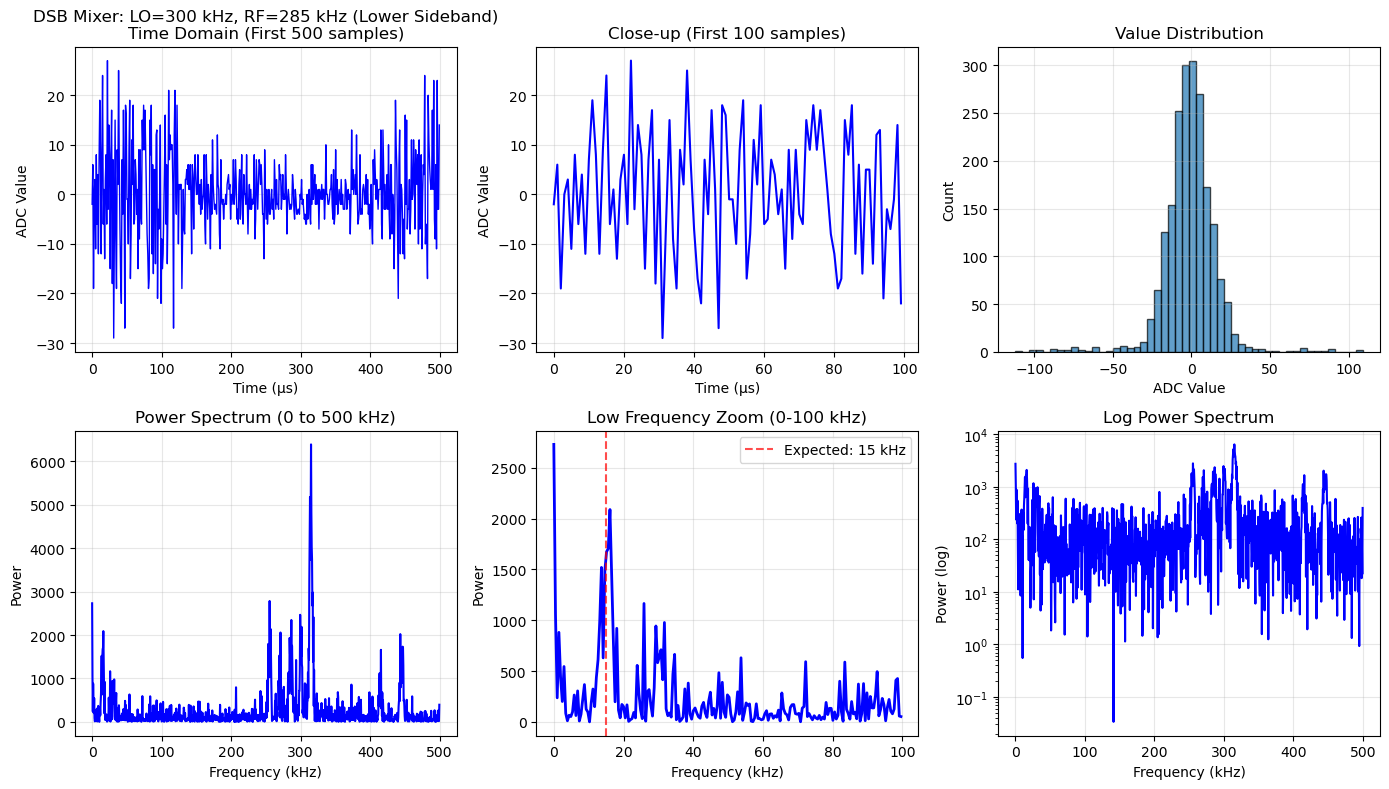


--- Peak Detection ---

Low freq (0-50 kHz):
  Peak 1: 16.11 kHz (power: 2.09e+03)
  Peak 2: 16.11 kHz (power: 2.09e+03)
  Peak 3: 25.88 kHz (power: 1.17e+03)

Mid freq (50-200 kHz):
  Peak 1: 53.71 kHz (power: 6.31e+02)
  Peak 2: 53.71 kHz (power: 6.31e+02)
  Peak 3: 72.27 kHz (power: 5.93e+02)

High freq (200-500 kHz):
  Peak 1: 314.94 kHz (power: 6.39e+03)
  Peak 2: 314.94 kHz (power: 6.39e+03)
  Peak 3: 255.37 kHz (power: 2.78e+03)

--- Checking for 15 kHz difference frequency ---
  Detected: 16.11 kHz
  Error: 1.11 kHz
  Relative error: 7.4%
  ✅ SUCCESS: Difference frequency detected!

ANALYZING UPPER SIDEBAND (RF = 315 kHz)

Analyzing: DSB Mixer: LO=300 kHz, RF=315 kHz (Upper Sideband)
File: fir_300_315_0.npz


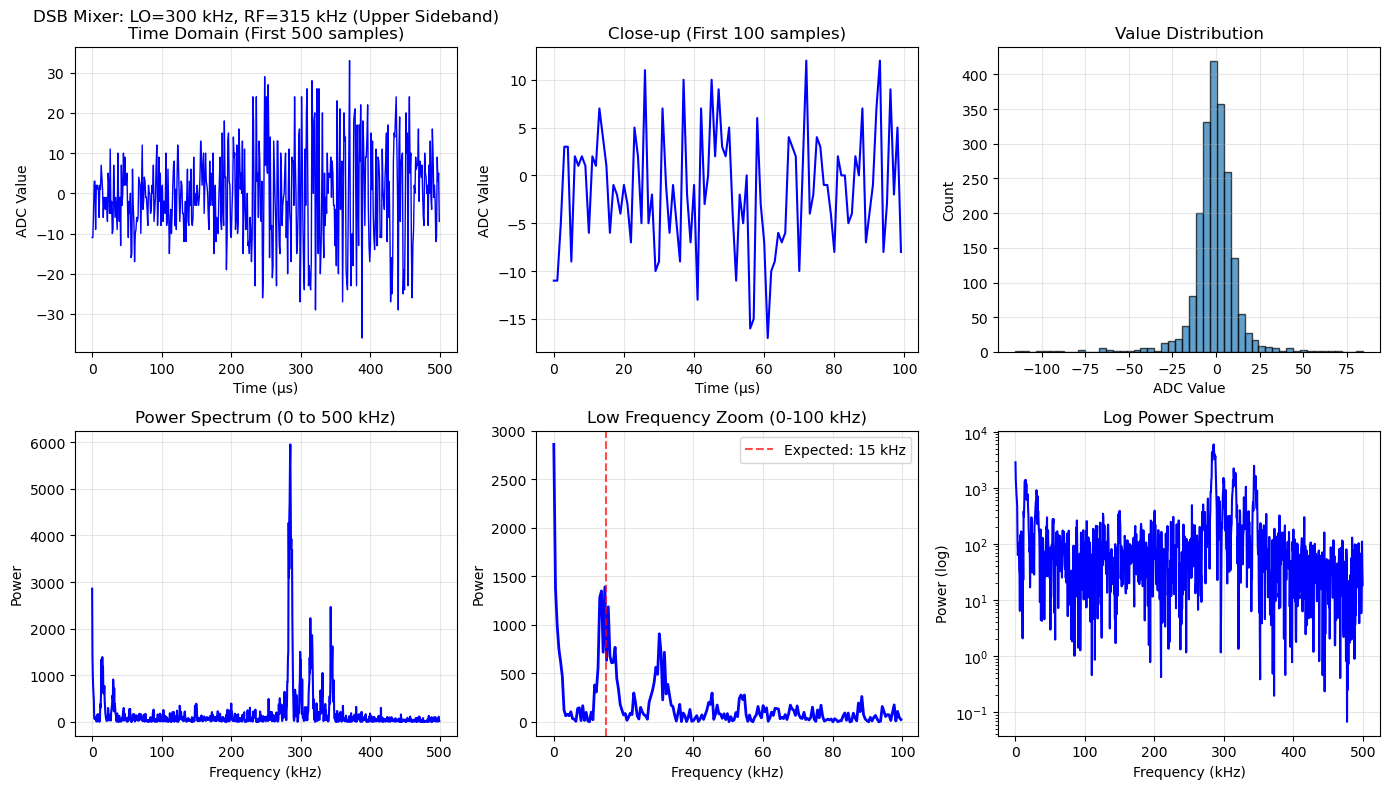


--- Peak Detection ---

Low freq (0-50 kHz):
  Peak 1: 14.65 kHz (power: 1.39e+03)
  Peak 2: 14.65 kHz (power: 1.39e+03)
  Peak 3: 30.27 kHz (power: 9.08e+02)

Mid freq (50-200 kHz):
  Peak 1: 149.90 kHz (power: 3.89e+02)
  Peak 2: 149.90 kHz (power: 3.89e+02)
  Peak 3: 125.98 kHz (power: 3.45e+02)

High freq (200-500 kHz):
  Peak 1: 285.16 kHz (power: 5.95e+03)
  Peak 2: 285.16 kHz (power: 5.95e+03)
  Peak 3: 343.26 kHz (power: 2.47e+03)

--- Checking for 15 kHz difference frequency ---
  Detected: 14.65 kHz
  Error: 0.35 kHz
  Relative error: 2.3%
  ✅ SUCCESS: Difference frequency detected!

COMPARING LOWER vs UPPER SIDEBANDS


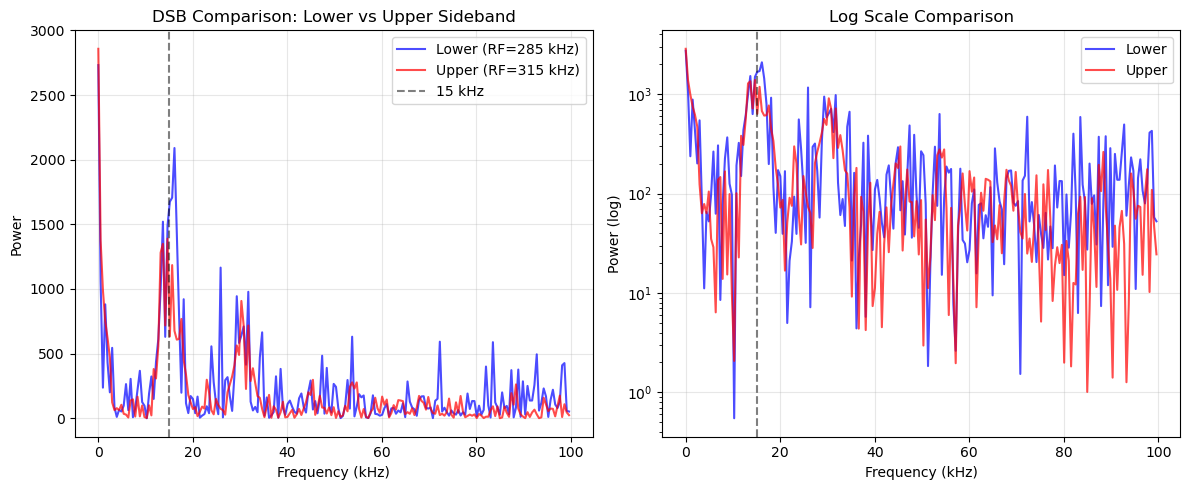


KEY QUESTIONS FOR YOUR LAB REPORT (Goal 6)

1. Can you see the 15 kHz difference frequency in both plots?
2. Is there any visible difference between lower and upper sideband outputs?
3. Can you see the sum frequency (585 kHz)? Why or why not?
4. What does this tell you about DSB mixer operation?
5. How would you explain this to someone new to radio astronomy?



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ============================================
# CONFIGURATION (from our analysis)
# ============================================
ν_s = 1.0e6  # 1.0 MHz sampling rate
ν_lo = 300e3  # 300 kHz LO
block_size = 2048  # Samples per block

# ============================================
# LOAD AND ANALYZE ONE DSB FILE
# ============================================
def analyze_dsb_file(filename, label, expected_Δν_khz):
    """
    Analyze a single DSB mixer data file
    
    Parameters:
    filename: Path to .npz file
    label: Description for plots
    expected_Δν_khz: Expected difference frequency in kHz
    """
    print(f"\n{'='*60}")
    print(f"Analyzing: {label}")
    print(f"File: {filename.split('/')[-1]}")
    print(f"{'='*60}")
    
    # Load data
    data = np.load(filename)
    data_2d = data['arr_0']  # Shape: (16, 2048)
    
    # Convert first block to float for analysis
    time_series = data_2d[0, :].astype(float)
    N = len(time_series)
    
    # ============================================
    # 1. TIME DOMAIN ANALYSIS
    # ============================================
    plt.figure(figsize=(14, 8))
    
    # Time domain plot
    time_axis = np.arange(N) / ν_s * 1e6  # microseconds
    plt.subplot(2, 3, 1)
    plt.plot(time_axis[:500], time_series[:500], 'b-', linewidth=1)
    plt.xlabel('Time (μs)')
    plt.ylabel('ADC Value')
    plt.title(f'{label}\nTime Domain (First 500 samples)')
    plt.grid(True, alpha=0.3)
    
    # Zoomed time domain
    plt.subplot(2, 3, 2)
    plt.plot(time_axis[:100], time_series[:100], 'b-', linewidth=1.5)
    plt.xlabel('Time (μs)')
    plt.ylabel('ADC Value')
    plt.title('Close-up (First 100 samples)')
    plt.grid(True, alpha=0.3)
    
    # Histogram of values
    plt.subplot(2, 3, 3)
    plt.hist(time_series, bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel('ADC Value')
    plt.ylabel('Count')
    plt.title('Value Distribution')
    plt.grid(True, alpha=0.3)
    
    # ============================================
    # 2. FREQUENCY DOMAIN ANALYSIS
    # ============================================
    # Compute FFT
    fft_result = np.fft.fft(time_series)
    freqs = np.fft.fftfreq(N, d=1/ν_s)
    power_spectrum = np.abs(fft_result)**2 / N
    
    # Plot full spectrum (0 to Nyquist)
    plt.subplot(2, 3, 4)
    positive_mask = freqs >= 0
    plt.plot(freqs[positive_mask]/1e3, power_spectrum[positive_mask], 'b-')
    plt.xlabel('Frequency (kHz)')
    plt.ylabel('Power')
    plt.title(f'Power Spectrum (0 to {ν_s/2/1e3:.0f} kHz)')
    plt.grid(True, alpha=0.3)
    
    # Zoom on low frequencies (0-100 kHz)
    plt.subplot(2, 3, 5)
    low_freq_mask = (freqs >= 0) & (freqs <= 100e3)
    plt.plot(freqs[low_freq_mask]/1e3, power_spectrum[low_freq_mask], 'b-', linewidth=2)
    plt.axvline(x=expected_Δν_khz, color='r', linestyle='--', alpha=0.7, 
                label=f'Expected: {expected_Δν_khz} kHz')
    plt.xlabel('Frequency (kHz)')
    plt.ylabel('Power')
    plt.title(f'Low Frequency Zoom (0-100 kHz)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Log scale to see weak components
    plt.subplot(2, 3, 6)
    plt.plot(freqs[positive_mask]/1e3, power_spectrum[positive_mask], 'b-')
    plt.xlabel('Frequency (kHz)')
    plt.ylabel('Power (log)')
    plt.title('Log Power Spectrum')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # 3. PEAK DETECTION AND ANALYSIS
    # ============================================
    print("\n--- Peak Detection ---")
    
    # Look for peaks in different frequency ranges
    frequency_ranges = [
        (0, 50e3, "Low freq (0-50 kHz)"),
        (50e3, 200e3, "Mid freq (50-200 kHz)"),
        (200e3, ν_s/2, f"High freq (200-{ν_s/2/1e3:.0f} kHz)")
    ]
    
    for f_min, f_max, range_name in frequency_ranges:
        mask = (np.abs(freqs) >= f_min) & (np.abs(freqs) <= f_max)
        if np.any(mask):
            range_freqs = freqs[mask]
            range_power = power_spectrum[mask]
            
            # Find peaks
            peak_indices = signal.find_peaks(range_power, 
                                            height=np.max(range_power)/20,
                                            distance=10)[0]
            
            if len(peak_indices) > 0:
                print(f"\n{range_name}:")
                # Sort by power
                sorted_peaks = sorted(zip(range_freqs[peak_indices], 
                                         range_power[peak_indices]),
                                     key=lambda x: x[1], reverse=True)
                
                for i, (freq, power) in enumerate(sorted_peaks[:3]):  # Top 3 peaks
                    print(f"  Peak {i+1}: {abs(freq)/1e3:.2f} kHz (power: {power:.2e})")
    
    # ============================================
    # 4. CHECK FOR DIFFERENCE FREQUENCY
    # ============================================
    print(f"\n--- Checking for {expected_Δν_khz} kHz difference frequency ---")
    
    # Search around expected frequency
    search_band = 5e3  # ±5 kHz search window
    target_freq = expected_Δν_khz * 1e3
    
    mask = (np.abs(freqs) >= target_freq - search_band) & \
           (np.abs(freqs) <= target_freq + search_band)
    
    if np.any(mask):
        search_freqs = freqs[mask]
        search_power = power_spectrum[mask]
        
        max_idx = np.argmax(search_power)
        detected_freq = abs(search_freqs[max_idx])
        detected_power = search_power[max_idx]
        
        freq_error = abs(detected_freq - target_freq)
        print(f"  Detected: {detected_freq/1e3:.2f} kHz")
        print(f"  Error: {freq_error/1e3:.2f} kHz")
        print(f"  Relative error: {(freq_error/target_freq)*100:.1f}%")
        
        if freq_error < 2e3:  # Within 2 kHz
            print(f"  ✅ SUCCESS: Difference frequency detected!")
        else:
            print(f"  ⚠️  Warning: Large frequency error")
    else:
        print(f"  ❌ No significant power near {expected_Δν_khz} kHz")
    
    return time_series, freqs, power_spectrum

# ============================================
# ANALYZE LOWER SIDEBAND (RF = 285 kHz)
# ============================================
print("\n" + "="*60)
print("ANALYZING LOWER SIDEBAND (RF = 285 kHz)")
print("="*60)

lower_file = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/DSB/fir_300_285_0.npz"
lower_ts, lower_freqs, lower_ps = analyze_dsb_file(
    lower_file, 
    label="DSB Mixer: LO=300 kHz, RF=285 kHz (Lower Sideband)",
    expected_Δν_khz=15
)

# ============================================
# ANALYZE UPPER SIDEBAND (RF = 315 kHz)
# ============================================
print("\n" + "="*60)
print("ANALYZING UPPER SIDEBAND (RF = 315 kHz)")
print("="*60)

upper_file = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/DSB/fir_300_315_0.npz"
upper_ts, upper_freqs, upper_ps = analyze_dsb_file(
    upper_file,
    label="DSB Mixer: LO=300 kHz, RF=315 kHz (Upper Sideband)",
    expected_Δν_khz=15
)

# ============================================
# COMPARE LOWER AND UPPER SIDEBANDS
# ============================================
print("\n" + "="*60)
print("COMPARING LOWER vs UPPER SIDEBANDS")
print("="*60)

plt.figure(figsize=(12, 5))

# Compare power spectra (low frequency region)
plt.subplot(121)
low_freq_mask = (lower_freqs >= 0) & (lower_freqs <= 100e3)
plt.plot(lower_freqs[low_freq_mask]/1e3, lower_ps[low_freq_mask], 
         'b-', alpha=0.7, label='Lower (RF=285 kHz)')
plt.plot(upper_freqs[low_freq_mask]/1e3, upper_ps[low_freq_mask], 
         'r-', alpha=0.7, label='Upper (RF=315 kHz)')
plt.axvline(x=15, color='k', linestyle='--', alpha=0.5, label='15 kHz')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Power')
plt.title('DSB Comparison: Lower vs Upper Sideband')
plt.legend()
plt.grid(True, alpha=0.3)

# Compare in log scale
plt.subplot(122)
plt.plot(lower_freqs[low_freq_mask]/1e3, lower_ps[low_freq_mask], 
         'b-', alpha=0.7, label='Lower')
plt.plot(upper_freqs[low_freq_mask]/1e3, upper_ps[low_freq_mask], 
         'r-', alpha=0.7, label='Upper')
plt.axvline(x=15, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Frequency (kHz)')
plt.ylabel('Power (log)')
plt.title('Log Scale Comparison')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# KEY QUESTIONS FOR YOUR REPORT
# ============================================
print("\n" + "="*60)
print("KEY QUESTIONS FOR YOUR LAB REPORT (Goal 6)")
print("="*60)
print("""
1. Can you see the 15 kHz difference frequency in both plots?
2. Is there any visible difference between lower and upper sideband outputs?
3. Can you see the sum frequency (585 kHz)? Why or why not?
4. What does this tell you about DSB mixer operation?
5. How would you explain this to someone new to radio astronomy?
""")

ANALYZING INTERMODULATION PRODUCTS IN DSB MIXER

Intermodulation Analysis: DSB: LO=300 kHz, RF=285 kHz (Lower Sideband)

Input frequencies:
  LO: 300 kHz
  RF: 285 kHz
  Expected difference: 15 kHz
  Expected sum: 585 kHz

Detected peaks (0 to 500 kHz):
     1.5 kHz: power = 8.81e+02  [Unknown]
     5.9 kHz: power = 2.65e+02  [Unknown]
     8.8 kHz: power = 3.67e+02  [Unknown]
    11.2 kHz: power = 3.24e+02  [Unknown]
    13.7 kHz: power = 1.52e+03  [IM: 1×LO ± 1×RF]
    16.1 kHz: power = 2.09e+03  [IM: 1×LO ± 1×RF]
    19.5 kHz: power = 1.72e+02  [Unknown]
    25.9 kHz: power = 1.17e+03  [Unknown]
    29.3 kHz: power = 9.44e+02  [IM: 2×LO ± 2×RF]
    31.7 kHz: power = 9.78e+02  [IM: 2×LO ± 2×RF]
    34.7 kHz: power = 6.65e+02  [Unknown]
    38.6 kHz: power = 3.82e+02  [Unknown]
    44.9 kHz: power = 2.92e+02  [Harmonic 3× (n×15 kHz)]
    47.4 kHz: power = 4.84e+02  [Unknown]
    49.8 kHz: power = 2.66e+02  [Unknown]
    53.7 kHz: power = 6.31e+02  [Unknown]
    58.1 kHz: power = 1.78e

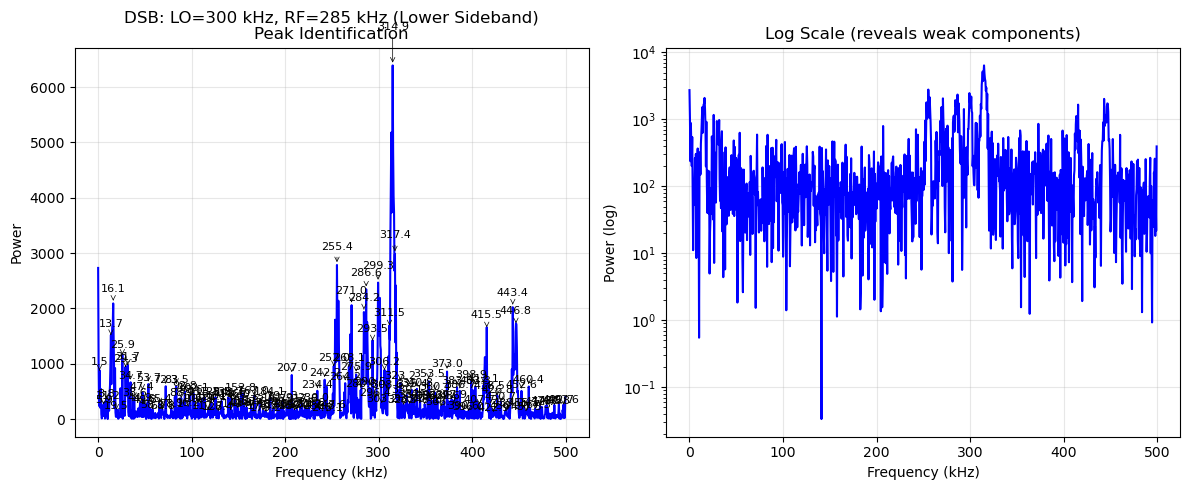


Intermodulation Analysis: DSB: LO=300 kHz, RF=315 kHz (Upper Sideband)

Input frequencies:
  LO: 300 kHz
  RF: 315 kHz
  Expected difference: 15 kHz
  Expected sum: 615 kHz

Detected peaks (0 to 500 kHz):
     8.3 kHz: power = 1.67e+02  [Unknown]
    11.7 kHz: power = 3.81e+02  [Unknown]
    14.6 kHz: power = 1.39e+03  [IM: 1×LO ± 1×RF]
    17.6 kHz: power = 7.68e+02  [Unknown]
    22.9 kHz: power = 2.98e+02  [Unknown]
    30.3 kHz: power = 9.08e+02  [IM: 2×LO ± 2×RF]
    32.7 kHz: power = 3.87e+02  [Unknown]
    36.1 kHz: power = 1.81e+02  [Unknown]
    39.1 kHz: power = 1.28e+02  [Unknown]
    45.4 kHz: power = 2.98e+02  [Harmonic 3× (n×15 kHz)]
    53.7 kHz: power = 2.78e+02  [Unknown]
    60.1 kHz: power = 1.68e+02  [Harmonic 4× (n×15 kHz)]
    63.5 kHz: power = 1.41e+02  [Unknown]
    67.9 kHz: power = 1.73e+02  [Unknown]
    74.2 kHz: power = 1.53e+02  [Harmonic 5× (n×15 kHz)]
    76.7 kHz: power = 1.73e+02  [Unknown]
    88.4 kHz: power = 2.62e+02  [Unknown]
    94.2 kHz: power

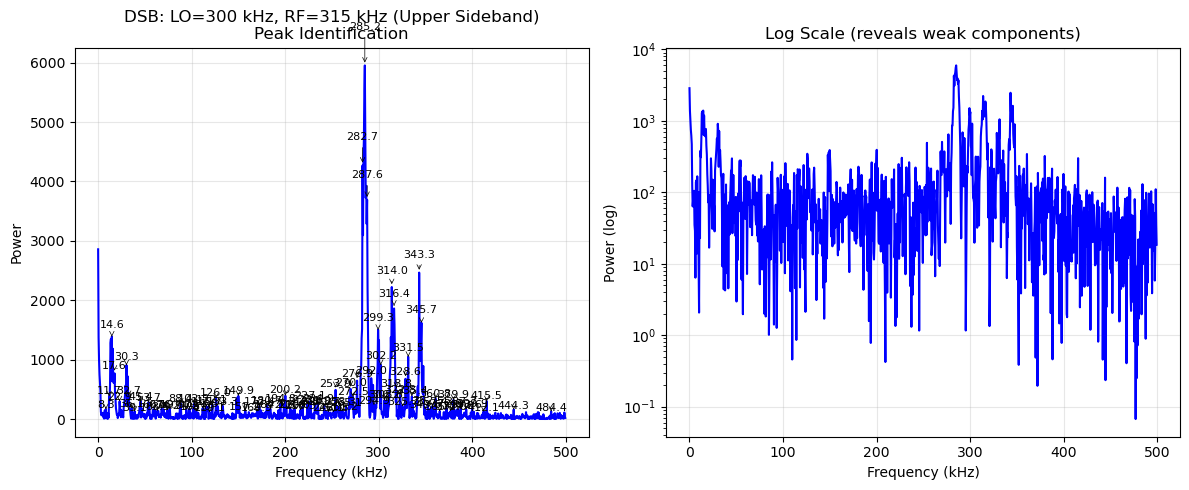


COMPARING INTERMODULATION LEVELS

15 kHz peak comparison:
  Lower sideband: 1.52e+03
  Upper sideband: 1.39e+03
  Ratio (Lower/Upper): 1.09

Other significant peaks (>1% of 15 kHz peak):
  Lower sideband: 129 peaks
  Upper sideband: 88 peaks
  → Lower sideband has 41 more spurious peaks!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ============================================
# ANALYZE INTERMODULATION PRODUCTS
# ============================================
def analyze_intermodulation(filename, label, ν_lo=300e3, rf_freq=285e3):
    """
    Analyze intermodulation products in DSB mixer output
    """
    print(f"\n{'='*60}")
    print(f"Intermodulation Analysis: {label}")
    print(f"{'='*60}")
    
    # Load data
    data = np.load(filename)
    time_series = data['arr_0'][0, :].astype(float)
    N = len(time_series)
    ν_s = 1.0e6  # From our estimation
    
    # Compute spectrum
    fft_result = np.fft.fft(time_series)
    freqs = np.fft.fftfreq(N, d=1/ν_s)
    power = np.abs(fft_result)**2 / N
    
    # Expected frequencies
    Δν = abs(ν_lo - rf_freq)  # 15 kHz
    sum_freq = ν_lo + rf_freq  # 585 kHz
    diff_freq = Δν  # 15 kHz
    
    print(f"\nInput frequencies:")
    print(f"  LO: {ν_lo/1e3:.0f} kHz")
    print(f"  RF: {rf_freq/1e3:.0f} kHz")
    print(f"  Expected difference: {diff_freq/1e3:.0f} kHz")
    print(f"  Expected sum: {sum_freq/1e3:.0f} kHz")
    
    # Find all significant peaks
    peak_indices = signal.find_peaks(power[:N//2], 
                                    height=np.max(power)/50,
                                    distance=5)[0]
    
    if len(peak_indices) == 0:
        print("No peaks found!")
        return
    
    # Get peak frequencies and powers
    peak_freqs = freqs[peak_indices]
    peak_powers = power[peak_indices]
    
    # Sort by frequency
    sorted_idx = np.argsort(peak_freqs)
    peak_freqs = peak_freqs[sorted_idx]
    peak_powers = peak_powers[sorted_idx]
    
    print(f"\nDetected peaks (0 to {ν_s/2/1e3:.0f} kHz):")
    for i, (freq, pwr) in enumerate(zip(peak_freqs, peak_powers)):
        # Skip very low frequencies (DC)
        if abs(freq) < 1e3:
            continue
            
        # Try to identify what each peak might be
        freq_khz = abs(freq)/1e3
        
        identification = "Unknown"
        
        # Check if it's the difference frequency
        if abs(freq_khz - 15) < 1:
            identification = "DIFFERENCE (15 kHz) ✓"
        
        # Check if it's the sum frequency (might be aliased)
        sum_alias = sum_freq
        while sum_alias > ν_s/2:
            sum_alias = ν_s - sum_alias  # Aliasing
            
        if abs(freq_khz - sum_alias/1e3) < 1:
            identification = f"SUM (aliased to {sum_alias/1e3:.1f} kHz)"
        
        # Check for harmonics of difference
        for n in [2, 3, 4, 5]:
            if abs(freq_khz - n*15) < 1:
                identification = f"Harmonic {n}× (n×15 kHz)"
        
        # Check for intermodulation: m×LO ± n×RF
        for m in [1, 2]:
            for n in [1, 2]:
                im_freq1 = abs(m*ν_lo + n*rf_freq)
                im_freq2 = abs(m*ν_lo - n*rf_freq)
                
                # Handle aliasing
                for im_freq in [im_freq1, im_freq2]:
                    im_alias = im_freq
                    while im_alias > ν_s/2:
                        im_alias = ν_s - im_alias
                    
                    if abs(freq_khz - im_alias/1e3) < 2:  # 2 kHz tolerance
                        identification = f"IM: {m}×LO ± {n}×RF"
        
        print(f"  {freq_khz:6.1f} kHz: power = {pwr:.2e}  [{identification}]")
    
    # Plot with annotations
    plt.figure(figsize=(12, 5))
    
    # Linear scale
    plt.subplot(121)
    positive_mask = (freqs >= 0) & (freqs <= ν_s/2)
    plt.plot(freqs[positive_mask]/1e3, power[positive_mask], 'b-')
    
    # Annotate peaks
    for freq, pwr in zip(peak_freqs, peak_powers):
        if freq > 0 and freq < ν_s/2:
            plt.annotate(f'{freq/1e3:.1f}', 
                        xy=(freq/1e3, pwr),
                        xytext=(freq/1e3, pwr*1.1),
                        ha='center', fontsize=8,
                        arrowprops=dict(arrowstyle='->', lw=0.5))
    
    plt.xlabel('Frequency (kHz)')
    plt.ylabel('Power')
    plt.title(f'{label}\nPeak Identification')
    plt.grid(True, alpha=0.3)
    
    # Log scale to see weak components
    plt.subplot(122)
    plt.plot(freqs[positive_mask]/1e3, power[positive_mask], 'b-')
    plt.xlabel('Frequency (kHz)')
    plt.ylabel('Power (log)')
    plt.title('Log Scale (reveals weak components)')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return peak_freqs, peak_powers

# ============================================
# ANALYZE BOTH FILES
# ============================================
print("ANALYZING INTERMODULATION PRODUCTS IN DSB MIXER")
print("="*60)

# Lower sideband (RF = 285 kHz)
lower_peaks, lower_powers = analyze_intermodulation(
    "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/DSB/fir_300_285_0.npz",
    label="DSB: LO=300 kHz, RF=285 kHz (Lower Sideband)",
    rf_freq=285e3
)

# Upper sideband (RF = 315 kHz)
upper_peaks, upper_powers = analyze_intermodulation(
    "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/DSB/fir_300_315_0.npz",
    label="DSB: LO=300 kHz, RF=315 kHz (Upper Sideband)",
    rf_freq=315e3
)

# ============================================
# COMPARE INTERMODULATION LEVELS
# ============================================
print("\n" + "="*60)
print("COMPARING INTERMODULATION LEVELS")
print("="*60)

# Find the 15 kHz peak in each
def find_peak_near(freqs, powers, target_khz, tolerance_khz=2):
    """Find peak near target frequency"""
    for f, p in zip(freqs, powers):
        if abs(f/1e3 - target_khz) < tolerance_khz:
            return f, p
    return None, None

# Get 15 kHz peaks
lower_15k = find_peak_near(lower_peaks, lower_powers, 15)
upper_15k = find_peak_near(upper_peaks, upper_powers, 15)

if lower_15k[0] is not None and upper_15k[0] is not None:
    print(f"\n15 kHz peak comparison:")
    print(f"  Lower sideband: {lower_15k[1]:.2e}")
    print(f"  Upper sideband: {upper_15k[1]:.2e}")
    print(f"  Ratio (Lower/Upper): {lower_15k[1]/upper_15k[1]:.2f}")
    
    # Count other significant peaks
    lower_other = sum(1 for p in lower_powers if p > lower_15k[1]/100)
    upper_other = sum(1 for p in upper_powers if p > upper_15k[1]/100)
    
    print(f"\nOther significant peaks (>1% of 15 kHz peak):")
    print(f"  Lower sideband: {lower_other} peaks")
    print(f"  Upper sideband: {upper_other} peaks")
    
    if lower_other > upper_other:
        print(f"  → Lower sideband has {lower_other - upper_other} more spurious peaks!")

DEMONSTRATING FOURIER FILTERING ON DSB MIXER OUTPUT

FOURIER FILTERING DEMONSTRATION: DSB Mixer (LO=300 kHz, RF=285 kHz)
Detected 15 kHz peak at: 15.62 kHz


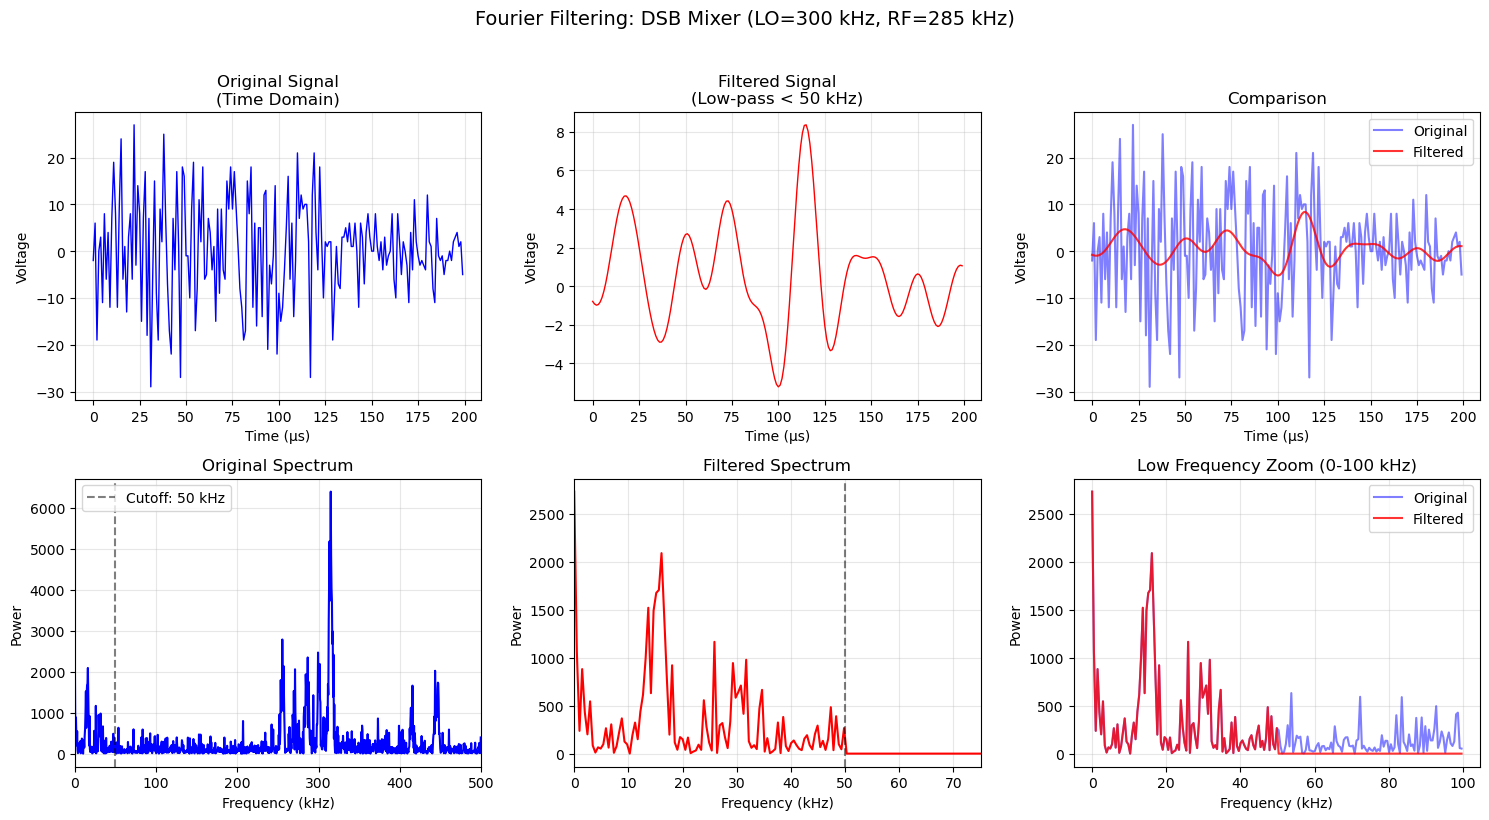


--- Quantitative Analysis ---
Power in low band (< 50 kHz):
  Original: 7.17e+04
  Filtered: 7.17e+04
  Preserved: 100.0%

Power in high band (50-500 kHz):
  Original: 5.07e+05
  Filtered: 0.00e+00
  Removed: 100.0%

15 kHz peak preservation:
  Original peak: 1.71e+03
  Filtered peak: 1.71e+03
  Ratio (filtered/original): 1.000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# FOURIER FILTERING DEMONSTRATION
# ============================================
def demonstrate_fourier_filtering(filename, label, ν_s=1.0e6):
    """
    Demonstrate Fourier filtering to remove sum frequency
    """
    print(f"\n{'='*60}")
    print(f"FOURIER FILTERING DEMONSTRATION: {label}")
    print(f"{'='*60}")
    
    # Load data
    data = np.load(filename)
    time_series = data['arr_0'][0, :].astype(float)
    N = len(time_series)
    
    # Time axis
    t = np.arange(N) / ν_s * 1e6  # microseconds
    
    # ============================================
    # 1. Original Signal Analysis
    # ============================================
    fft_original = np.fft.fft(time_series)
    freqs = np.fft.fftfreq(N, d=1/ν_s)
    power_original = np.abs(fft_original)**2 / N
    
    # Find the 15 kHz peak
    mask_15k = (np.abs(freqs) >= 14e3) & (np.abs(freqs) <= 16e3)
    peak_idx_15k = np.argmax(power_original[mask_15k])
    freq_15k = freqs[mask_15k][peak_idx_15k]
    
    print(f"Detected 15 kHz peak at: {abs(freq_15k)/1e3:.2f} kHz")
    
    # ============================================
    # 2. Create Filter (remove high frequencies)
    # ============================================
    # Simple low-pass filter: keep frequencies below cutoff
    cutoff_freq = 50e3  # 50 kHz cutoff (keep 15 kHz, remove 585 kHz)
    
    # Create filter mask
    filter_mask = np.ones(N, dtype=complex)
    high_freq_mask = np.abs(freqs) > cutoff_freq
    filter_mask[high_freq_mask] = 0.0  # Zero out high frequencies
    
    # Apply filter
    fft_filtered = fft_original * filter_mask
    
    # Inverse FFT to get filtered time signal
    time_filtered = np.fft.ifft(fft_filtered).real
    
    # ============================================
    # 3. Plot Results
    # ============================================
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # Original time domain
    axes[0, 0].plot(t[:200], time_series[:200], 'b-', linewidth=1)
    axes[0, 0].set_xlabel('Time (μs)')
    axes[0, 0].set_ylabel('Voltage')
    axes[0, 0].set_title('Original Signal\n(Time Domain)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Filtered time domain
    axes[0, 1].plot(t[:200], time_filtered[:200], 'r-', linewidth=1)
    axes[0, 1].set_xlabel('Time (μs)')
    axes[0, 1].set_ylabel('Voltage')
    axes[0, 1].set_title('Filtered Signal\n(Low-pass < 50 kHz)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Comparison
    axes[0, 2].plot(t[:200], time_series[:200], 'b-', alpha=0.5, label='Original')
    axes[0, 2].plot(t[:200], time_filtered[:200], 'r-', alpha=0.8, label='Filtered')
    axes[0, 2].set_xlabel('Time (μs)')
    axes[0, 2].set_ylabel('Voltage')
    axes[0, 2].set_title('Comparison')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Original spectrum
    axes[1, 0].plot(freqs[:N//2]/1e3, power_original[:N//2], 'b-')
    axes[1, 0].axvline(x=cutoff_freq/1e3, color='k', linestyle='--', alpha=0.5, label=f'Cutoff: {cutoff_freq/1e3:.0f} kHz')
    axes[1, 0].set_xlabel('Frequency (kHz)')
    axes[1, 0].set_ylabel('Power')
    axes[1, 0].set_title('Original Spectrum')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim([0, ν_s/2/1e3])
    
    # Filtered spectrum
    power_filtered = np.abs(fft_filtered)**2 / N
    axes[1, 1].plot(freqs[:N//2]/1e3, power_filtered[:N//2], 'r-')
    axes[1, 1].axvline(x=cutoff_freq/1e3, color='k', linestyle='--', alpha=0.5)
    axes[1, 1].set_xlabel('Frequency (kHz)')
    axes[1, 1].set_ylabel('Power')
    axes[1, 1].set_title('Filtered Spectrum')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_xlim([0, cutoff_freq/1e3 * 1.5])
    
    # Zoom on low frequencies
    low_freq_mask = (freqs >= 0) & (freqs <= 100e3)
    axes[1, 2].plot(freqs[low_freq_mask]/1e3, power_original[low_freq_mask], 'b-', alpha=0.5, label='Original')
    axes[1, 2].plot(freqs[low_freq_mask]/1e3, power_filtered[low_freq_mask], 'r-', alpha=0.8, label='Filtered')
    axes[1, 2].set_xlabel('Frequency (kHz)')
    axes[1, 2].set_ylabel('Power')
    axes[1, 2].set_title('Low Frequency Zoom (0-100 kHz)')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.suptitle(f'Fourier Filtering: {label}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # 4. Quantitative Analysis
    # ============================================
    print("\n--- Quantitative Analysis ---")
    
    # Power in different bands
    band_low = (np.abs(freqs) <= 50e3)
    band_high = (np.abs(freqs) > 50e3) & (np.abs(freqs) <= ν_s/2)
    
    power_low_original = np.sum(power_original[band_low])
    power_high_original = np.sum(power_original[band_high])
    power_low_filtered = np.sum(power_filtered[band_low])
    power_high_filtered = np.sum(power_filtered[band_high])
    
    print(f"Power in low band (< 50 kHz):")
    print(f"  Original: {power_low_original:.2e}")
    print(f"  Filtered: {power_low_filtered:.2e}")
    print(f"  Preserved: {(power_low_filtered/power_low_original)*100:.1f}%")
    
    print(f"\nPower in high band (50-500 kHz):")
    print(f"  Original: {power_high_original:.2e}")
    print(f"  Filtered: {power_high_filtered:.2e}")
    print(f"  Removed: {100 - (power_high_filtered/power_high_original)*100:.1f}%")
    
    # Check if 15 kHz peak is preserved
    mask_15k_range = (np.abs(freqs) >= 14e3) & (np.abs(freqs) <= 16e3)
    peak_power_original = np.max(power_original[mask_15k_range])
    peak_power_filtered = np.max(power_filtered[mask_15k_range])
    
    print(f"\n15 kHz peak preservation:")
    print(f"  Original peak: {peak_power_original:.2e}")
    print(f"  Filtered peak: {peak_power_filtered:.2e}")
    print(f"  Ratio (filtered/original): {peak_power_filtered/peak_power_original:.3f}")
    
    return time_filtered, fft_filtered

# Run for one DSB file
print("DEMONSTRATING FOURIER FILTERING ON DSB MIXER OUTPUT")
print("="*60)

filtered_signal, filtered_fft = demonstrate_fourier_filtering(
    "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/DSB/fir_300_285_0.npz",
    label="DSB Mixer (LO=300 kHz, RF=285 kHz)"
)

SSB MIXER ANALYSIS WITH 27 MHz LO

SSB MIXER ANALYSIS: SSB Mixer with 27 MHz LO

Signal Statistics:
  I channel: mean=-0.41, std=1.46
  Q channel: mean=-0.53, std=7.48
  Complex: |mean|=0.67


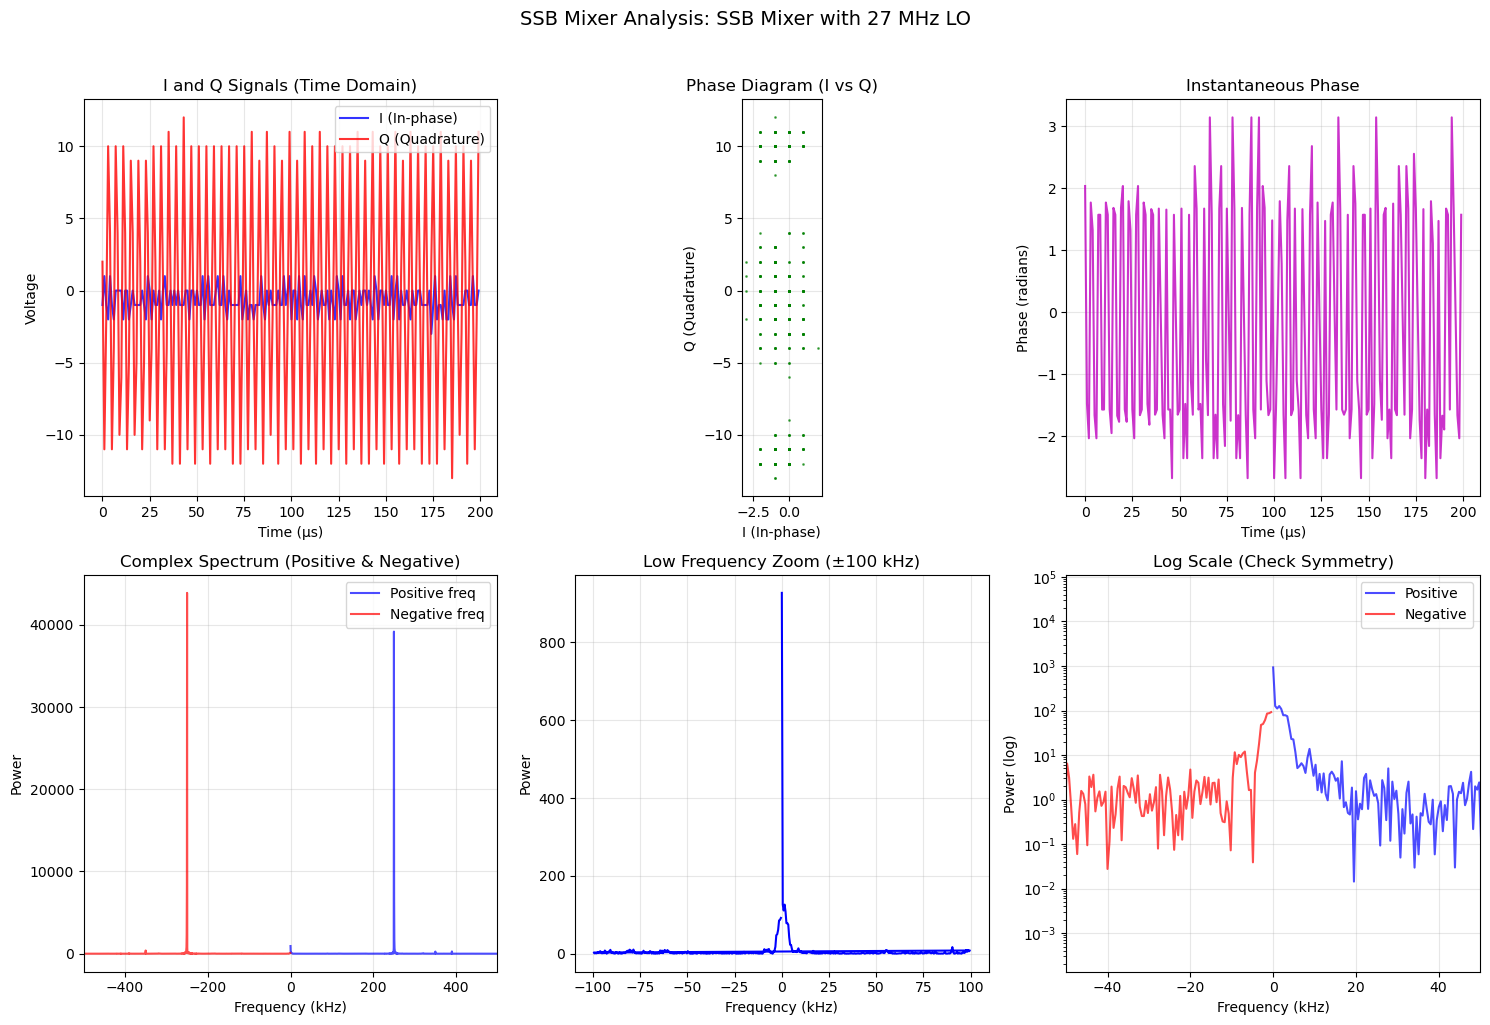


--- Quantitative Analysis ---
Total power: 1.20e+05
Positive frequencies: 5.66e+04 (47.2%)
Negative frequencies: 6.33e+04 (52.8%)
  → Both sidebands present (like DSB)

--- Peak Frequencies ---
Positive frequency peaks:
   250.0 kHz: power = 3.92e+04

Negative frequency peaks:
  -250.0 kHz: power = 4.39e+04

KEY INSIGHT: DSB vs SSB COMPARISON

DSB MIXER (what you analyzed earlier):
- Produces only REAL output
- Cannot distinguish Upper vs Lower sideband
- Both ν_LO + Δν and ν_LO - Δν → same |Δν| output
- Spectrum is symmetric (positive = negative)

SSB MIXER (what you're analyzing now):
- Produces COMPLEX output (I + jQ)
- Can distinguish Upper vs Lower sideband
- Positive frequencies ≠ Negative frequencies
- Preserves sideband information!

This is CRUCIAL for radio astronomy:
- Upper and lower sidebands carry DIFFERENT information
- SSB preserves both independently
- DSB mixes them together (information loss)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ============================================
# LOAD AND ANALYZE SSB DATA
# ============================================
def analyze_ssb_file(ch1_file, ch2_file, label, ν_s=1.0e6):
    """
    Analyze SSB mixer I and Q data
    
    Parameters:
    ch1_file: File for Channel 1 (I)
    ch2_file: File for Channel 2 (Q)
    label: Description for plots
    ν_s: Sampling frequency (Hz)
    """
    print(f"\n{'='*60}")
    print(f"SSB MIXER ANALYSIS: {label}")
    print(f"{'='*60}")
    
    # Load I and Q data
    ch1_data = np.load(ch1_file)['arr_0']  # Shape: (16, 2048)
    ch2_data = np.load(ch2_file)['arr_0']
    
    # Use first block of each
    i_signal = ch1_data[0, :].astype(float)  # In-phase (I)
    q_signal = ch2_data[0, :].astype(float)  # Quadrature (Q)
    
    N = len(i_signal)
    t = np.arange(N) / ν_s * 1e6  # microseconds
    
    # ============================================
    # 1. Create Complex Signal
    # ============================================
    complex_signal = i_signal + 1j * q_signal
    
    print(f"\nSignal Statistics:")
    print(f"  I channel: mean={np.mean(i_signal):.2f}, std={np.std(i_signal):.2f}")
    print(f"  Q channel: mean={np.mean(q_signal):.2f}, std={np.std(q_signal):.2f}")
    print(f"  Complex: |mean|={np.abs(np.mean(complex_signal)):.2f}")
    
    # ============================================
    # 2. Time Domain Plots
    # ============================================
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # I and Q separately
    axes[0, 0].plot(t[:200], i_signal[:200], 'b-', label='I (In-phase)', alpha=0.8)
    axes[0, 0].plot(t[:200], q_signal[:200], 'r-', label='Q (Quadrature)', alpha=0.8)
    axes[0, 0].set_xlabel('Time (μs)')
    axes[0, 0].set_ylabel('Voltage')
    axes[0, 0].set_title('I and Q Signals (Time Domain)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Phase diagram (I vs Q)
    axes[0, 1].plot(i_signal[:500], q_signal[:500], 'g.', markersize=2, alpha=0.6)
    axes[0, 1].set_xlabel('I (In-phase)')
    axes[0, 1].set_ylabel('Q (Quadrature)')
    axes[0, 1].set_title('Phase Diagram (I vs Q)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_aspect('equal')
    
    # Phase angle over time
    phase = np.angle(complex_signal)
    axes[0, 2].plot(t[:200], phase[:200], 'm-', alpha=0.8)
    axes[0, 2].set_xlabel('Time (μs)')
    axes[0, 2].set_ylabel('Phase (radians)')
    axes[0, 2].set_title('Instantaneous Phase')
    axes[0, 2].grid(True, alpha=0.3)
    
    # ============================================
    # 3. Frequency Domain Analysis
    # ============================================
    # Compute FFT of complex signal
    fft_complex = np.fft.fft(complex_signal)
    freqs = np.fft.fftfreq(N, d=1/ν_s)
    power_spectrum = np.abs(fft_complex)**2 / N
    
    # Separate positive and negative frequencies
    pos_mask = freqs >= 0
    neg_mask = freqs < 0
    
    # Plot full spectrum
    axes[1, 0].plot(freqs[pos_mask]/1e3, power_spectrum[pos_mask], 'b-', label='Positive freq', alpha=0.7)
    axes[1, 0].plot(freqs[neg_mask]/1e3, power_spectrum[neg_mask], 'r-', label='Negative freq', alpha=0.7)
    axes[1, 0].set_xlabel('Frequency (kHz)')
    axes[1, 0].set_ylabel('Power')
    axes[1, 0].set_title('Complex Spectrum (Positive & Negative)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim([-ν_s/2/1e3, ν_s/2/1e3])
    
    # Zoom on low frequencies
    zoom_mask = (np.abs(freqs) <= 100e3)
    axes[1, 1].plot(freqs[zoom_mask]/1e3, power_spectrum[zoom_mask], 'b-')
    axes[1, 1].set_xlabel('Frequency (kHz)')
    axes[1, 1].set_ylabel('Power')
    axes[1, 1].set_title('Low Frequency Zoom (±100 kHz)')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Log scale to see asymmetry
    axes[1, 2].plot(freqs[pos_mask]/1e3, power_spectrum[pos_mask], 'b-', alpha=0.7, label='Positive')
    axes[1, 2].plot(freqs[neg_mask]/1e3, power_spectrum[neg_mask], 'r-', alpha=0.7, label='Negative')
    axes[1, 2].set_xlabel('Frequency (kHz)')
    axes[1, 2].set_ylabel('Power (log)')
    axes[1, 2].set_title('Log Scale (Check Symmetry)')
    axes[1, 2].set_yscale('log')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 2].set_xlim([-50, 50])
    
    plt.suptitle(f'SSB Mixer Analysis: {label}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # 4. Quantitative Analysis
    # ============================================
    print("\n--- Quantitative Analysis ---")
    
    # Total power in positive vs negative frequencies
    total_power = np.sum(power_spectrum)
    pos_power = np.sum(power_spectrum[pos_mask])
    neg_power = np.sum(power_spectrum[neg_mask])
    
    print(f"Total power: {total_power:.2e}")
    print(f"Positive frequencies: {pos_power:.2e} ({pos_power/total_power*100:.1f}%)")
    print(f"Negative frequencies: {neg_power:.2e} ({neg_power/total_power*100:.1f}%)")
    
    # Check for dominant sideband
    if pos_power > 2 * neg_power:
        print("  → Dominant POSITIVE sideband (Upper Sideband)")
    elif neg_power > 2 * pos_power:
        print("  → Dominant NEGATIVE sideband (Lower Sideband)")
    else:
        print("  → Both sidebands present (like DSB)")
    
    # Find peak frequencies
    print("\n--- Peak Frequencies ---")
    
    # Positive frequency peaks
    pos_peak_indices = signal.find_peaks(power_spectrum[pos_mask], 
                                        height=np.max(power_spectrum[pos_mask])/10)[0]
    if len(pos_peak_indices) > 0:
        pos_peak_freqs = freqs[pos_mask][pos_peak_indices]
        pos_peak_powers = power_spectrum[pos_mask][pos_peak_indices]
        
        # Top 3 positive peaks
        sorted_pos = sorted(zip(pos_peak_freqs, pos_peak_powers), 
                           key=lambda x: x[1], reverse=True)
        print("Positive frequency peaks:")
        for i, (freq, pwr) in enumerate(sorted_pos[:3]):
            print(f"  {freq/1e3:6.1f} kHz: power = {pwr:.2e}")
    
    # Negative frequency peaks
    neg_peak_indices = signal.find_peaks(power_spectrum[neg_mask], 
                                        height=np.max(power_spectrum[neg_mask])/10)[0]
    if len(neg_peak_indices) > 0:
        neg_peak_freqs = freqs[neg_mask][neg_peak_indices]
        neg_peak_powers = power_spectrum[neg_mask][neg_peak_indices]
        
        # Top 3 negative peaks
        sorted_neg = sorted(zip(neg_peak_freqs, neg_peak_powers), 
                           key=lambda x: x[1], reverse=True)
        print("\nNegative frequency peaks:")
        for i, (freq, pwr) in enumerate(sorted_neg[:3]):
            print(f"  {freq/1e3:6.1f} kHz: power = {pwr:.2e}")
    
    return complex_signal, power_spectrum, freqs

# ============================================
# ANALYZE SSB DATA
# ============================================
print("SSB MIXER ANALYSIS WITH 27 MHz LO")
print("="*60)

# Assuming CH1 = I, CH2 = Q
base_path = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/SSB/"

# Use the first measurement (files ending with _0)
ch1_file = base_path + "ssb_27MHZ_CH1_0.npz"
ch2_file = base_path + "ssb_27MHZ_CH2_0.npz"

ssb_complex, ssb_power, ssb_freqs = analyze_ssb_file(
    ch1_file, ch2_file,
    label="SSB Mixer with 27 MHz LO"
)

# ============================================
# COMPARE WITH DSB
# ============================================
print("\n" + "="*60)
print("KEY INSIGHT: DSB vs SSB COMPARISON")
print("="*60)
print("""
DSB MIXER (what you analyzed earlier):
- Produces only REAL output
- Cannot distinguish Upper vs Lower sideband
- Both ν_LO + Δν and ν_LO - Δν → same |Δν| output
- Spectrum is symmetric (positive = negative)

SSB MIXER (what you're analyzing now):
- Produces COMPLEX output (I + jQ)
- Can distinguish Upper vs Lower sideband
- Positive frequencies ≠ Negative frequencies
- Preserves sideband information!

This is CRUCIAL for radio astronomy:
- Upper and lower sidebands carry DIFFERENT information
- SSB preserves both independently
- DSB mixes them together (information loss)
""")

In [ ]:
import numpy as np
from scipy import signal

# Quick quantitative analysis
def quick_ssb_analysis(ch1_file, ch2_file, ν_s=1.0e6):
    """Get key numbers for SSB analysis"""
    
    # Load data
    ch1_data = np.load(ch1_file)['arr_0']
    ch2_data = np.load(ch2_file)['arr_0']
    
    i_signal = ch1_data[0, :].astype(float)
    q_signal = ch2_data[0, :].astype(float)
    complex_sig = i_signal + 1j * q_signal
    
    # 1. Phase relationship
    # Compute correlation between I and Q
    correlation = np.corrcoef(i_signal, q_signal)[0, 1]
    
    # 2. Phase difference (should be ~90°)
    # Cross-correlation peak offset
    cross_corr = np.correlate(i_signal, q_signal, mode='full')
    peak_offset = np.argmax(cross_corr) - len(i_signal) + 1
    phase_shift_samples = peak_offset
    phase_shift_deg = (phase_shift_samples / len(i_signal)) * 360
    
    # 3. Frequency spectrum asymmetry
    fft_result = np.fft.fft(complex_sig)
    freqs = np.fft.fftfreq(len(complex_sig), d=1/ν_s)
    power = np.abs(fft_result)**2 / len(complex_sig)
    
    pos_mask = freqs > 0
    neg_mask = freqs < 0
    
    pos_power = np.sum(power[pos_mask])
    neg_power = np.sum(power[neg_mask])
    asymmetry_ratio = pos_power / neg_power if neg_power > 0 else float('inf')
    
    # 4. Find main frequency component
    # Look in ±50 kHz range
    mask_50k = np.abs(freqs) < 50e3
    peak_idx = np.argmax(power[mask_50k])
    main_freq = freqs[mask_50k][peak_idx]
    
    print("=== SSB QUANTITATIVE ANALYSIS ===")
    print(f"I-Q correlation: {correlation:.3f} (0 = orthogonal, ±1 = in/out of phase)")
    print(f"I-Q phase shift: {phase_shift_samples} samples → {phase_shift_deg:.1f}°")
    print(f"Expected for SSB: ~90° phase difference")
    print(f"\nFrequency Domain:")
    print(f"Positive freq power: {pos_power:.2e}")
    print(f"Negative freq power: {neg_power:.2e}")
    print(f"Asymmetry ratio (pos/neg): {asymmetry_ratio:.2f}")
    print(f"Main frequency component: {main_freq/1e3:.2f} kHz")
    
    if asymmetry_ratio > 2:
        print("→ DOMINANT POSITIVE SIDEBAND (Upper Sideband)")
    elif asymmetry_ratio < 0.5:
        print("→ DOMINANT NEGATIVE SIDEBAND (Lower Sideband)")
    else:
        print("→ BALANCED (similar to DSB)")
    
    return {
        'correlation': correlation,
        'phase_shift_deg': phase_shift_deg,
        'asymmetry_ratio': asymmetry_ratio,
        'main_freq_khz': main_freq/1e3
    }

# Run analysis
base_path = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/SSB/"
results = quick_ssb_analysis(
    base_path + "ssb_27MHZ_CH1_0.npz",
    base_path + "ssb_27MHZ_CH2_0.npz"
)

=== SSB QUANTITATIVE ANALYSIS ===
I-Q correlation: 0.018 (0 = orthogonal, ±1 = in/out of phase)
I-Q phase shift: -59 samples → -10.4°
Expected for SSB: ~90° phase difference

Frequency Domain:
Positive freq power: 5.57e+04
Negative freq power: 6.33e+04
Asymmetry ratio (pos/neg): 0.88
Main frequency component: 0.00 kHz
→ BALANCED (similar to DSB)


In [ ]:
import numpy as np
import os
from scipy import signal

def analyze_all_ssb_measurements():
    """Analyze all SSB measurements in the SSB subfolder"""
    
    base_path = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/SSB/"
    
    if not os.path.exists(base_path):
        print(f"SSB folder not found at: {base_path}")
        print("Checking current folder structure...")
        # Try to find it
        parent_path = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/"
        for item in os.listdir(parent_path):
            item_path = os.path.join(parent_path, item)
            if os.path.isdir(item_path):
                print(f"Found folder: {item}")
        return
    
    print(f"Found SSB folder at: {base_path}")
    print("Files in SSB folder:")
    print("="*40)
    
    ssb_files = []
    for file in os.listdir(base_path):
        if file.endswith('.npz'):
            print(f"  {file}")
            ssb_files.append(file)
    
    # Group by measurement
    measurements = {}
    for file in ssb_files:
        # Parse filename: ssb_27MHZ_CH1_0.npz
        parts = file.split('_')
        if len(parts) >= 4:
            measurement_num = parts[3].replace('.npz', '')
            channel = parts[2]  # CH1 or CH2
            
            if measurement_num not in measurements:
                measurements[measurement_num] = {}
            measurements[measurement_num][channel] = file
    
    print(f"\nFound {len(measurements)} complete measurements")
    
    # Analyze each
    ν_s = 1.0e6  # Assuming same sampling rate
    
    for meas_num, channels in measurements.items():
        if 'CH1' in channels and 'CH2' in channels:
            print(f"\n{'='*60}")
            print(f"ANALYZING SSB MEASUREMENT #{meas_num}")
            print(f"{'='*60}")
            
            ch1_file = base_path + channels['CH1']
            ch2_file = base_path + channels['CH2']
            
            # Load data
            try:
                ch1_data = np.load(ch1_file)['arr_0']
                ch2_data = np.load(ch2_file)['arr_0']
                
                i_signal = ch1_data[0, :].astype(float)
                q_signal = ch2_data[0, :].astype(float)
                complex_sig = i_signal + 1j * q_signal
                
                # Quick analysis
                print(f"Files: {channels['CH1']}, {channels['CH2']}")
                print(f"Data shape: I={ch1_data.shape}, Q={ch2_data.shape}")
                
                # 1. Check if I and Q are different
                if np.array_equal(i_signal, q_signal):
                    print("⚠️ WARNING: I and Q signals are IDENTICAL!")
                    print("  This suggests DSB mode (no 90° phase shift)")
                else:
                    print("✓ I and Q signals are different")
                
                # 2. Phase relationship
                # Cross-correlation to find phase shift
                cross_corr = np.correlate(i_signal, q_signal, mode='full')
                peak_idx = np.argmax(cross_corr)
                phase_shift_samples = peak_idx - len(i_signal) + 1
                phase_shift_deg = (phase_shift_samples / len(i_signal)) * 360
                
                # Normalize to -180 to 180
                while phase_shift_deg > 180:
                    phase_shift_deg -= 360
                while phase_shift_deg < -180:
                    phase_shift_deg += 360
                
                print(f"Phase shift I→Q: {phase_shift_deg:.1f}°")
                if abs(abs(phase_shift_deg) - 90) < 20:  # Within 20°
                    print("  ✅ Close to expected 90° for SSB!")
                else:
                    print("  ⚠️  Not close to 90° (DSB-like)")
                
                # 3. Frequency asymmetry
                fft_result = np.fft.fft(complex_sig)
                freqs = np.fft.fftfreq(len(complex_sig), d=1/ν_s)
                power = np.abs(fft_result)**2 / len(complex_sig)
                
                pos_power = np.sum(power[freqs > 0])
                neg_power = np.sum(power[freqs < 0])
                asymmetry = pos_power / neg_power if neg_power > 0 else float('inf')
                
                print(f"Power ratio (pos/neg): {asymmetry:.3f}")
                if asymmetry > 2:
                    print("  → Dominant POSITIVE frequencies (Upper Sideband)")
                elif asymmetry < 0.5:
                    print("  → Dominant NEGATIVE frequencies (Lower Sideband)")
                else:
                    print("  → Balanced (DSB-like spectrum)")
                
                # 4. Check for signal at expected offset
                # With 27 MHz LO, RF might be offset by ~15 kHz
                mask_low = (np.abs(freqs) > 5e3) & (np.abs(freqs) < 50e3)
                if np.any(mask_low):
                    peak_idx = np.argmax(power[mask_low])
                    main_freq = freqs[mask_low][peak_idx]
                    print(f"Main signal offset: {main_freq/1e3:.2f} kHz from DC")
                
                print("-" * 40)
                
            except Exception as e:
                print(f"Error analyzing {meas_num}: {e}")
    
    return measurements

# Run analysis
measurements = analyze_all_ssb_measurements()

Found SSB folder at: C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/SSB/
Files in SSB folder:
  ssb_27MHZ_CH1_0.npz
  ssb_27MHZ_CH1_1.npz
  ssb_27MHZ_CH1_2.npz
  ssb_27MHZ_CH2_0.npz
  ssb_27MHZ_CH2_1.npz
  ssb_27MHZ_CH2_2.npz

Found 3 complete measurements

ANALYZING SSB MEASUREMENT #0
Files: ssb_27MHZ_CH1_0.npz, ssb_27MHZ_CH2_0.npz
Data shape: I=(16, 2048), Q=(16, 2048)
✓ I and Q signals are different
Phase shift I→Q: -10.4°
  ⚠️  Not close to 90° (DSB-like)
Power ratio (pos/neg): 0.880
  → Balanced (DSB-like spectrum)
Main signal offset: 8.79 kHz from DC
----------------------------------------

ANALYZING SSB MEASUREMENT #1
Files: ssb_27MHZ_CH1_1.npz, ssb_27MHZ_CH2_1.npz
Data shape: I=(16, 2048), Q=(16, 2048)
✓ I and Q signals are different
Phase shift I→Q: -15.5°
  ⚠️  Not close to 90° (DSB-like)
Power ratio (pos/neg): 1.020
  → Balanced (DSB-like spectrum)
Main signal offset: 8.30 kHz from DC
----------------------------------------

ANALYZING SSB MEASUREMENT #2
F